# Take home project: treatment effect prediction

Suppose we have patients with a disease that tends to cause an undesirable event (e.g., death) at some time after diagnosis. Patients with more severe disease tend to experience this event eariler, and patients with less severe disease tend to experience it later. Doctors administer treatment to some of their patients, hoping that it will delay the undesirable event for as long as possible. However, the doctors are generally unsure of which patients actually benefit from the treatment and which patients do not. Your task is to help the doctors make their treatment decisions by **building and evaluating a model that predicts treatment effects for patients.**

## Data

The `patient_records.json` file contains a dataset of 5000 patient records that you will use to train and evaluate your model. Within each patient record, we have a collection of input embeddings, treatment information, and outcomes:

```python
{
    "embeddings": [[...], [...], ...],  # variable-length list of 4D vectors
    "treatment": 0 or 1,                # 1 if the patient was treated
    "event": 0 or 1,                    # 1 if the undesirable event was observed
    "duration": float,                  # time to event or last contact
}
```
The embeddings can be thought of as encoding various facets of the patient's pre-treatment disease state. Treatment is encoded as a binary indicator, taking a value of 1 if the patient received treatment and 0 if they did not. The event and duration data combine to encode the patient's outcome. Every patient has an underlying event time, but we don't always observe this event time. In some cases, we lose contact with the patient before they experience the event, in which case their recorded duration is the time till our last contact with the patient. Thus, the event indicator tells us whether the recorded duration is (1) the true time till event or (0) the last known event-free time for the patient. Both the input embeddings and the treatment indicator may contain missing values. 

You will also be given an `inference_inputs.json` that contains the embeddings and treatment information for 10k patients in a randomized control trial. You will not be given the outcomes for these patients. After you train your model, you should generate treatment effect predictions for all patients in `inference_inputs.json` and submit these predictions alongside your code. The `fake_inference_outcomes.json` contains _fake_ placeholder outcomes for the patients in `inference_inputs.json`, and may be used to help you debug your evaluation code in section 4 (see below). 

## Tasks

### 1. Formalize the problem setup and your plan

We've given you a problem statement that is intentially vague: "build something that takes in patient information and outputs a prediction of their treatment benefit". It's up to you to flesh out the details of how to turn this into a well-defined machine learning problem. In a few paragraphs, explain how you interpret the problem, and your approach for solving it. Some points you may want to include:

- _What exactly is the quantity that you will be predicting?_ There are multiple ways to formalize the notation of "treatment effect". Choose one that you think is most appropriate for our setting, and explain.
- _How do you plan to use the available data?_ It's up to you to define data splits and data cleaning/preprocessing procedures where appropriate. 
- _What models and training schemes will you use?_ Choose a model architecture (or a class of architectures), and explain why they are a good choice for the task. Explain how you plan to train them.
- _How will you structure your model development?_ It's unlikely that you'll create your favorite model on the first try. You might have to iterate a bit to get to a model you like. Explain how you plan to structure your development process.
- _How will you evaluate your model?_ Explain what metric(s) you will use to measure whether your model is "good" or not. 
- _State assumptions!_ If any of the modeling, training, or evaluation procedures you described rest upon assumptions about the data or the task, state them clearly!

### 2. Build your model

Code and train your model(s)! If you decide to train multiple models, choose one to be the "final" model that you'd deploy for the doctors.

### 3. Report

Evaluate your final model on (a split of) the `patient_records.json` data, and report the results. Explain whether the results were stronger or weaker than you would have expected. Identify a few ways that you could potentially improve your model. We are interested in hearing about both immediate improvements (pretend you had a few more days to work on this), as well as long term research directions (pretend you were going to work on a problem like this for months/years).

### 4. External Evaluation

You were given embeddings and treatment data for 10k randomized control trial patients in the `inference_inputs.json` file. You should run inference on this data, producing a treatment effect prediction for each patient. Submit your predictions alongside your code. Create a cell at the bottom of this notebook which may be used to evaluate your predictions when given access to an array of outcomes. That is, you should choose an evaluation metric(s) that you believe is appropriate for evaluating your model on a randomized control trial, and then you should code a function that takes in the path to a json file of patient outcomes and computes the evaluation metric(s) on your inference predictions. You can use the placeholder outcomes in `fake_inference_outcomes.json` to debug your evaluation function. All package imports and other helper code for your evaluation function should be contained in the same notebook cell as the evaluation function -- we should be able to simply replace the `fake_inference_outcomes.json` path with the path to the real outcomes and run this cell to compute the evaluation metric(s). In addition to the evaluation code, you should write a brief explanation (just a few sentences) of why your chosen evaluation metric(s) is appropriate, and (approximately) what values of the metric(s) would indicate a "poor" model, a "good" model, and a "great" model. 

### 5. Deploy!

Package your final model into a "deployment-ready" docker container, and submit it alongside this notebook. It should be very easy for us to load your model and run inference on new patients.

### General Note:
Please submit all scratch work alongside your final "production" code. For example, any exploratory data analysis should be done directly in this notebook (or in another notebook that you include in your submission). If the model development process involves you trying out multiple model design candidates and selecting the best one, we'd like to see the code you used to iterate and experiment (even if some of the candidates performed poorly!), as opposed to just the code used to train your final model. Written answers should be included directly in this notebook as markdown cells. Coding can be done in both this notebook and other auxiliary files if needed. Please do not spend more than 8 hours on this. Feel free to use AI assistance.

Finally, **we do not expect you to submit a perfect solution -- we are much more interested in seeing your _process_ towards reaching a reasonable solution.** The signal to noise ratio in this dataset in low, and the input embeddings do not perfectly explain the outcomes, so adjust your expectations accordingly!

---
# My solution

Everything below is mine. The written answers are in markdown cells, the exploratory analysis and the experiments run in the code cells, and the reusable parts (data loading, features, learners, metrics, training and the inference CLI) live in `src/treatment_effect/` so that the notebook, the experiment script and the Docker container all run the same code. `README.md` has the layout and the commands.

Time units are whatever `duration` is measured in; I just call them "time units".

### How the pieces fit together

![architecture](figures/00_architecture.png)

Top to bottom: the json files are loaded and turned into 30 features per patient; patients with an unknown treatment are dropped and a test split is set aside; nuisance models (propensity, censoring, outcome) are fit on training folds only and feed both the meta-learners and the selection scores; 22 candidates are compared on the same folds; the chosen one is checked on the test split, refit on everyone, used to score the trial, and packaged in a container. `README.md` has the same diagram as Mermaid source and a longer walkthrough.

## 1. Problem setup and plan

### What I'm actually predicting

The doctors want to know, for the specific patient in front of them, how much the treatment is likely to delay the event. So the quantity I predict is the expected gain in event-free time over a fixed window:

$$\tau(x) = \mathbb{E}\big[\min(T_1, H) - \min(T_0, H) \mid x\big]$$

where $T_1$ and $T_0$ are the event times the patient would have with and without treatment and $H$ is a horizon. This is the difference in restricted mean survival time (RMST): a conditional average treatment effect on the time scale. I picked it over the alternatives for a few reasons.

- It is in the units the question is asked in. "On average this patient gains about 2 time units event-free in the next 20" is something a doctor can act on and a patient can understand. A hazard ratio is not.
- It needs no proportional hazards assumption, and unlike a hazard ratio it averages properly over patients (hazard ratios are non-collapsible, so a "mean hazard ratio" is not a meaningful thing).
- It is well defined under censoring and can be estimated in a randomized trial with plain Kaplan-Meier curves, no model required. That matters for section 4: the external check should not depend on my modelling choices.
- A survival probability at one time point ("event-free at 10") would also work, but it ignores everything that happens before that time. RMST integrates the whole curve up to $H$.

For the horizon I use $H = 20$. By then about 70% of patients have had the event, there are still 340 to 380 patients per arm at risk, and the Kaplan-Meier curves are well estimated. Past 25 the risk sets thin out quickly (under 200 per arm) and anything estimated there is mostly noise. Every patient gets the same quantity, so a doctor reads `predicted_effect = 1.8` as "treating is expected to buy 1.8 time units within the next 20". Positive means treat; negative means the treatment is expected to do no good, or harm, for this patient.

### What the data looks like, and what that changed in the plan

The first pass through the data (the cells right after this) changed four things about how I approached the problem.

1. **Treated patients look worse, not better.** 68.8% of treated patients had the event against 59.9% of controls, and the raw Kaplan-Meier curve of the treated arm sits below the control arm. The embeddings predict who gets treated with a cross-validated AUC of 0.70. Doctors treat the sicker patients, so this is confounding by indication, and a model that just learns "treated, therefore worse" would be exactly wrong. Every model below adjusts for the embeddings, and the ones I trust most use propensity scores on top. The propensity scores stay reasonably far from 0 and 1 (1st to 99th percentile: 0.12 to 0.88), so there is overlap to adjust with.
2. **Missingness is informative.** Dimensions 2 and 3 of the vectors are missing about a third of the time, and the share missing for a patient is strongly tied to the treatment decision (70% treated in the most complete quartile against 24% in the least complete) and to how long the patient is followed. I keep the missing rates as features rather than imputing them away.
3. **The embedding list is a set, and two of the dimensions are bimodal.** The order of the vectors carries nothing (means by position are flat). Dimensions 2 and 3 have a second mode around 3.3, separated from the main mode by a valley near 2.4. Vectors in that second mode behave like a flag, so on top of the usual summaries (mean, spread, extremes) I count them per patient. All features are permutation invariant.
4. **Censoring is not independent of the features.** A Cox model for the *censoring* time, given features and treatment, reaches a concordance of 0.71. That rules out the simplest way of turning censored times into regression targets (Kaplan-Meier pseudo-values), which assumes the opposite. Instead I weight each patient whose restricted outcome $\min(T, H)$ is actually observed by the inverse of their modelled probability of still being under follow-up (IPCW). The survival models (Cox, boosted survival trees, random survival forest) condition on the features anyway and only need the weaker assumption.

352 patients have no treatment recorded. Their embeddings look like everyone else's (AUC 0.56 for telling them apart), but their outcomes do not: 26% had the event, with a median follow-up of 22 against 7 for everyone else. I cannot learn an arm-specific outcome without the arm, so they are dropped from model fitting, but I flag it because it means the missing treatment is tied to the outcome in a way the data do not explain. The trial file has 736 such patients too. They still get a prediction, because $\tau(x)$ depends only on $x$, but they cannot enter any evaluation that needs the arm.

### How I use the data

- 4,648 patients with a known treatment. 20% of them (930, stratified on treatment × event) are the test split and are not touched until section 3.
- Model selection is 5-fold cross-validation on the remaining 3,718 (the development split), same stratification, same folds and same nuisance models for every candidate.
- The model that goes to the trial (section 4) and into the container (section 5) is refit on all 4,648.

Preprocessing is the feature extraction described above: 30 numbers per patient, computed by one function (`features.py`) that is shared by training, batch inference and the API. The set network additionally sees the raw vectors with a missing-value mask.

### Models and training

Low signal-to-noise and 3,700 training patients argue for simple, well-regularised effect models, and for putting the effort into the causal part rather than the architecture. I tried five families, from dumb to fancy.

- **Constant effect.** Everyone gets the adjusted average treatment effect. If nothing beats this, there is no usable heterogeneity.
- **Cox proportional hazards** with treatment as a covariate (the effect then varies only through baseline risk), and with treatment × feature interactions.
- **T-learners with survival models.** One model per arm (Cox, gradient boosted survival analysis, random survival forest), effect = difference of the two predicted RMSTs.
- **Meta-learners on the restricted outcome** $\min(T, H)$ with IPCW weights: S-, T-, X-, DR- and R-learners, with ridge regression or small gradient boosted trees as base learners. The DR-learner is the one I expected to do best. It combines a propensity model, two outcome models and cross-fitting into a pseudo-outcome whose regression on $x$ targets $\tau(x)$ directly, and it is doubly robust (either the propensity model or the outcome models can be wrong, not both; the censoring model has to be right in either case). I also ran DR and T on Kaplan-Meier pseudo-values, to see how much the censoring model matters.
- **A DeepSets network** on the raw vectors: per-vector MLP, mean and max pooling, a shared trunk and one discrete-time hazard head per arm, trained by maximum likelihood with early stopping. This is the "let the network find the features" option.

All of it is in `src/treatment_effect/models.py`; every candidate shares one `fit` / `predict` interface so the comparison code is identical for all of them.

### How development was structured

Baselines first, then the families above, all on the same folds with the same nuisance models, so differences are paired. The selection criterion is the one I can defend, not the one that looks best:

- The main score is the **DR-loss**: mean squared distance between a candidate's predictions and a doubly robust pseudo-outcome computed on the validation fold from nuisance models (propensity, censoring, outcome) fit on the training folds. Its absolute value is dominated by outcome noise, but ranking candidates by it is consistent for the true CATE mean squared error, and comparing each candidate with the constant baseline fold by fold removes most of that noise.
- Second, the **AUTOC** (area under the targeting operator characteristic; Yadlowsky et al., 2021): does ranking patients by predicted benefit pick out the patients who benefit? On observational folds this uses inverse-propensity × inverse-censoring weights.
- For candidates that also predict per-arm outcomes, Harrell's C-index, to see whether the outcome part learns anything.
- A second seed for the top candidates, to see how much of the ranking is luck, and a check whether averaging the best few beats the best one.

Within noise I take the simpler model. The test split then gives one honest number per metric for the chosen model, and the trial is the real exam.

### How the model is evaluated

Nobody observes both outcomes for the same patient, so there is no ground-truth effect to compute an error against. On observational data I use the proxies above. In the randomized trial, randomization makes subgroup effects estimable with Kaplan-Meier alone, so there I use (1) observed against predicted effect by predicted-benefit quintile, with a calibration slope, (2) the AUTOC with a bootstrap interval and a permutation p-value, and (3) a Cox interaction test between treatment and the score. Section 4 says what counts as poor, good and great for each.

### Assumptions, stated

- **No unmeasured confounding.** Given the embeddings, treatment assignment is as good as random. The embeddings are described as encoding the pre-treatment disease state, which is what the doctors decide on, so this is plausible, but it cannot be checked from the data.
- **Overlap.** Every patient had a real chance of either treatment. Checked: propensity scores within 0.12 to 0.88 for 98% of patients.
- **Censoring is independent of the event time given features and treatment**, and a Cox model captures that dependence well enough. Only the fit statistics can be checked.
- **Consistency and no interference.** "Treatment" is the same thing for everyone and one patient's treatment does not affect another's outcome.
- **The trial patients are the same kind of patients.** A classifier cannot tell training from trial patients (AUC 0.50), and treatment in the trial is unrelated to the features (AUC 0.52), as it should be in an RCT.
- **The effect is stable across time and sites**, and 20 time units is a horizon the doctors care about.

### Exploratory analysis

The numbers quoted above come from these cells.

In [1]:
import sys, json, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from treatment_effect.data import load_patients, load_outcomes
from treatment_effect.features import feature_matrix, FEATURE_NAMES, HIGH_MODE_THRESHOLD
from treatment_effect import metrics as M

pd.set_option("display.width", 160)
pd.set_option("display.precision", 3)

# one small visual system for every figure: control = blue, treated = orange, everything else recessive
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, MUTED, GRID, DIM = "#52514e", "#898781", "#e1e0d9", "#b5b3ab"
BLUES = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]  # ordered ramp, light to dark
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9.5, "axes.titlesize": 11, "axes.titlecolor": "#0b0b0b",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})

records = load_patients("data/patient_records.json")
rct = load_patients("data/inference_inputs.json")
df = records.to_frame()

print(f"training patients: {len(records)}   trial patients to score: {len(rct)}")
print(f"treated: {(df.treatment == 1).sum()}   control: {(df.treatment == 0).sum()}   treatment unknown: {df.treatment.isna().sum()}")
print(f"events observed: {df.event.sum()} ({df.event.mean():.1%}),  censored: {(df.event == 0).sum()}")
print("duration quantiles:", df.duration.quantile([0, .1, .25, .5, .75, .9, 1]).round(2).to_dict())
print("vectors per patient: min", df.n_vectors.min(), " max", df.n_vectors.max(), " mean", round(df.n_vectors.mean(), 1))
print("\nby arm (no adjustment):")
print(df[df.treatment.notna()].groupby("treatment").agg(n=("event", "size"), event_rate=("event", "mean"), median_duration=("duration", "median")).round(3))

training patients: 5000   trial patients to score: 10000
treated: 2308   control: 2340   treatment unknown: 352
events observed: 3080 (61.6%),  censored: 1920
duration quantiles: {0.0: 0.0, 0.1: 0.91, 0.25: 2.68, 0.5: 7.22, 0.75: 16.51, 0.9: 25.1, 1.0: 39.98}
vectors per patient: min 32  max 51  mean 41.5

by arm (no adjustment):
              n  event_rate  median_duration
treatment                                   
0.0        2340       0.599            6.634
1.0        2308       0.688            6.739


**Missing values.** Dimensions 0 and 1 are always present, 2 and 3 are missing about a third of the time. The share of missing values for a patient is tied to both the treatment decision and the follow-up time (table and figure below), so it goes into the features rather than being imputed away.

share of missing values per dimension: [0.    0.    0.319 0.318]

by quartile of a patient's missing share (dims 2 and 3):
                     n  treated_rate  event_rate  median_duration
missing_quartile                                                 
most complete     1275         0.701       0.559            4.475
q2                1233         0.562       0.622            6.620
q3                1242         0.461       0.651            7.808
least complete    1250         0.240       0.633           11.799


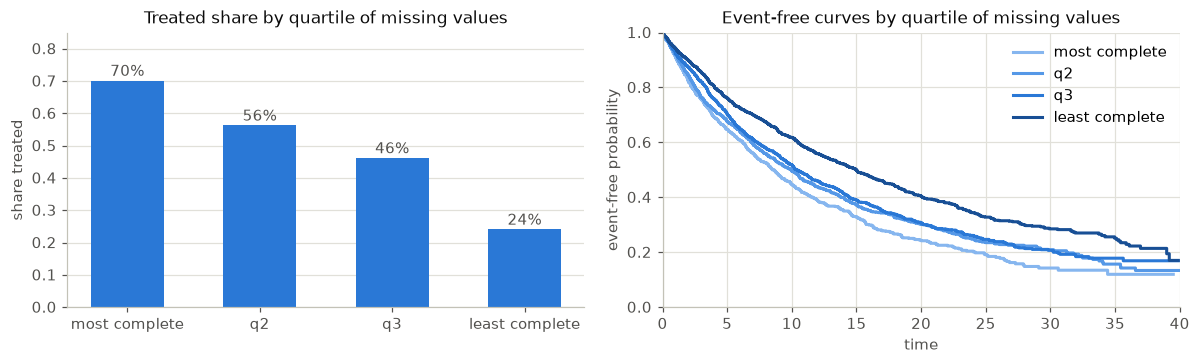

In [2]:
all_vecs = np.vstack(records.embeddings)
null_rate = np.isnan(all_vecs).mean(axis=0)
print("share of missing values per dimension:", null_rate.round(3))

df["missing_frac"] = [np.isnan(e[:, 2:]).mean() for e in records.embeddings]
quartile_names = ["most complete", "q2", "q3", "least complete"]
df["missing_quartile"] = pd.qcut(df.missing_frac, 4, labels=quartile_names)
by_q = df.groupby("missing_quartile", observed=True).agg(n=("event", "size"), treated_rate=("treatment", "mean"),
                                                         event_rate=("event", "mean"), median_duration=("duration", "median"))
print("\nby quartile of a patient's missing share (dims 2 and 3):")
print(by_q.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
ax.bar(quartile_names, by_q.treated_rate, width=0.55, color=BLUE)
for i, v in enumerate(by_q.treated_rate):
    ax.text(i, v + 0.015, f"{v:.0%}", ha="center", color=INK)
ax.set_ylim(0, 0.85); ax.grid(False, axis="x"); ax.set_ylabel("share treated"); ax.set_title("Treated share by quartile of missing values")
ax = axes[1]
for name, col in zip(quartile_names, BLUES):
    sub = df[df.missing_quartile == name]
    ut, S = M.kaplan_meier(sub.duration, sub.event)
    ax.step(np.r_[0, ut], np.r_[1, S], where="post", color=col, label=name)
ax.set_xlim(0, 40); ax.set_ylim(0, 1); ax.set_xlabel("time"); ax.set_ylabel("event-free probability")
ax.set_title("Event-free curves by quartile of missing values"); ax.legend()
plt.tight_layout(); plt.show()

**What the vectors look like.** Dimensions 2 and 3 have a clear second mode around 3.3 (dashed line: the threshold I use to count "high mode" vectors). Position in the list carries nothing, and the dimensions are nearly uncorrelated, so each patient is a bag of 4-d points and the features should be permutation invariant.

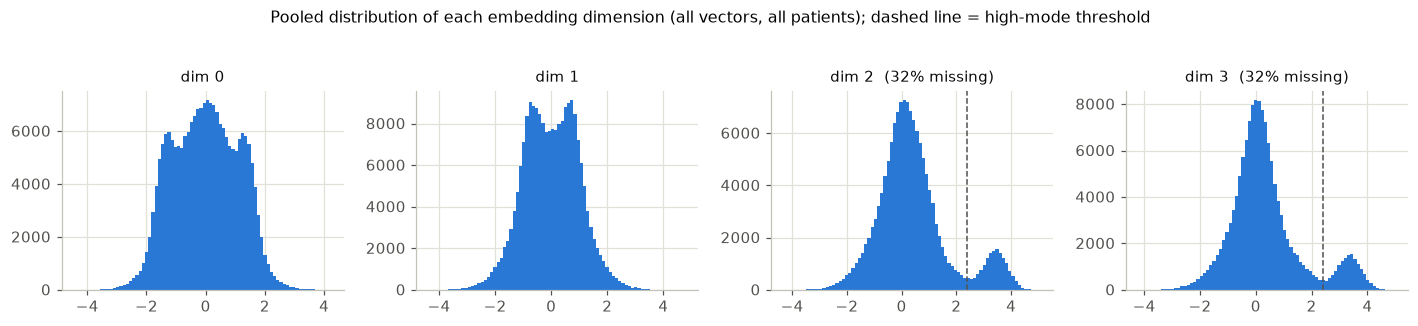

share of observed values above 2.4: dim 2 0.104, dim 3 0.102
mean of dim 0 by position in the list (first, middle, last): [-0.018, -0.022, -0.032]
correlation between dimensions (observed pairs):
       d0     d1     d2     d3
d0  1.000 -0.193  0.004  0.006
d1 -0.193  1.000  0.003  0.004
d2  0.004  0.003  1.000  0.096
d3  0.006  0.004  0.096  1.000


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for d, ax in enumerate(axes):
    col = all_vecs[:, d]
    ax.hist(col[~np.isnan(col)], bins=80, color=BLUE)
    ax.set_title(f"dim {d}" + ("" if d < 2 else f"  ({null_rate[d]:.0%} missing)"), fontsize=10)
    if d >= 2:
        ax.axvline(HIGH_MODE_THRESHOLD, color=INK, ls="--", lw=1)
plt.suptitle("Pooled distribution of each embedding dimension (all vectors, all patients); dashed line = high-mode threshold", y=1.04, fontsize=10.5)
plt.tight_layout(); plt.show()

hi2 = all_vecs[:, 2] > HIGH_MODE_THRESHOLD; hi3 = all_vecs[:, 3] > HIGH_MODE_THRESHOLD
print(f"share of observed values above {HIGH_MODE_THRESHOLD}: dim 2 {hi2[~np.isnan(all_vecs[:, 2])].mean():.3f}, dim 3 {hi3[~np.isnan(all_vecs[:, 3])].mean():.3f}")
pos = pd.DataFrame([(i, v[0]) for e in records.embeddings for i, v in enumerate(e)], columns=["pos", "d0"]).groupby("pos").d0.mean()
print("mean of dim 0 by position in the list (first, middle, last):", pos.iloc[[0, 20, 40]].round(3).tolist())
print("correlation between dimensions (observed pairs):")
print(pd.DataFrame(all_vecs, columns=[f"d{i}" for i in range(4)]).corr().round(3))

**Outcomes by arm, no adjustment.** The treated arm does worse in the raw curves, and treated patients are also followed longer (right panel). Both are what confounding by indication looks like. The table shows why $H = 20$: enough patients are still at risk there, and not many further out.

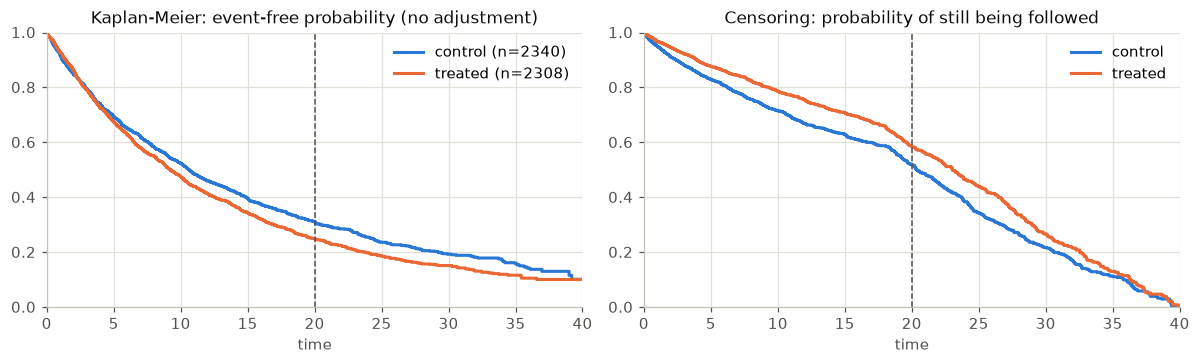

 horizon  S_control  at_risk_control  S_treated  at_risk_treated  raw_rmst_diff
       5      0.695             1348      0.675             1367          0.002
      10      0.524              877      0.476              864         -0.176
      15      0.397              585      0.343              561         -0.425
      20      0.311              377      0.249              338         -0.715
      25      0.236              190      0.186              189         -1.013
      30      0.193               98      0.152               93         -1.264


In [4]:
lab = df[df.treatment.notna()]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for arm, name, c in [(0, "control", BLUE), (1, "treated", ORANGE)]:
    sub = lab[lab.treatment == arm]
    ut, S = M.kaplan_meier(sub.duration, sub.event)
    axes[0].step(np.r_[0, ut], np.r_[1, S], where="post", label=f"{name} (n={len(sub)})", color=c)
    utc, G = M.kaplan_meier(sub.duration, 1 - sub.event)
    axes[1].step(np.r_[0, utc], np.r_[1, G], where="post", label=name, color=c)
axes[0].set_title("Kaplan-Meier: event-free probability (no adjustment)"); axes[0].set_xlabel("time"); axes[0].legend()
axes[1].set_title("Censoring: probability of still being followed"); axes[1].set_xlabel("time"); axes[1].legend()
for ax in axes:
    ax.axvline(20, color=INK, ls="--", lw=1); ax.set_xlim(0, 40); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

rows = []
for H in [5, 10, 15, 20, 25, 30]:
    r = {"horizon": H}
    for arm in (0, 1):
        sub = lab[lab.treatment == arm]
        ut, S = M.kaplan_meier(sub.duration, sub.event)
        r["S_control" if arm == 0 else "S_treated"] = float(M.survival_at(ut, S, H))
        r["at_risk_control" if arm == 0 else "at_risk_treated"] = int((sub.duration >= H).sum())
    r["raw_rmst_diff"] = M.ate_rmst(lab.duration.values, lab.event.values, lab.treatment.values, H)
    rows.append(r)
print(pd.DataFrame(rows).round(3).to_string(index=False))

**Confounding.** Who gets treated is predictable from the features (AUC 0.70), mostly through the level of dimensions 2 and 3 and the missing rates. There is still overlap: hardly anyone has a propensity below 0.1 or above 0.9. The right panel checks that the propensity model is calibrated (predicted probability against the observed treated share by decile), which matters because these probabilities become weights later.

cross-validated AUC for predicting who gets treated: 0.700
propensity quantiles (1%, 5%, 50%, 95%, 99%): [0.116 0.174 0.506 0.809 0.878]


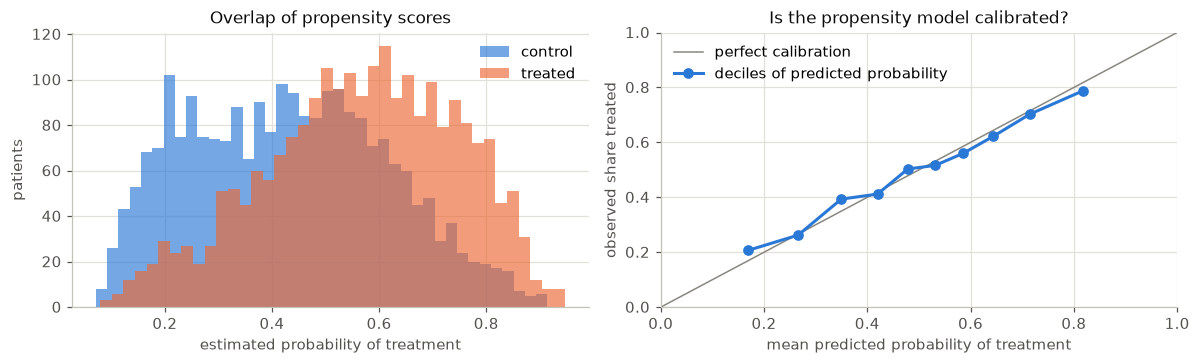

largest standardized logistic coefficients for treatment:
lo2_mean    0.619
d2_mean    -0.476
d3_mean     0.252
miss_d2    -0.241
hi3_frac   -0.227
miss_d3    -0.217


In [5]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from treatment_effect.models import make_classifier

X_all = feature_matrix(records.embeddings)
known = df.treatment.notna().values
w = df.treatment[known].astype(int).values
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
e_hat = cross_val_predict(make_classifier("gbm"), X_all[known], w, cv=cv5, method="predict_proba")[:, 1]
print(f"cross-validated AUC for predicting who gets treated: {roc_auc_score(w, e_hat):.3f}")
print("propensity quantiles (1%, 5%, 50%, 95%, 99%):", np.percentile(e_hat, [1, 5, 50, 95, 99]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
ax.hist(e_hat[w == 0], bins=40, alpha=.65, label="control", color=BLUE)
ax.hist(e_hat[w == 1], bins=40, alpha=.65, label="treated", color=ORANGE)
ax.set_xlabel("estimated probability of treatment"); ax.set_ylabel("patients"); ax.set_title("Overlap of propensity scores"); ax.legend()
ax = axes[1]
dec = pd.qcut(e_hat, 10, labels=False)
rel = pd.DataFrame({"pred": e_hat, "obs": w, "dec": dec}).groupby("dec").agg(pred=("pred", "mean"), obs=("obs", "mean"), n=("obs", "size"))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, label="perfect calibration")
ax.plot(rel.pred, rel.obs, "o-", color=BLUE, ms=6, label="deciles of predicted probability")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel("mean predicted probability of treatment"); ax.set_ylabel("observed share treated")
ax.set_title("Is the propensity model calibrated?"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

coef = pd.Series(LogisticRegression(C=1.0, max_iter=3000).fit(StandardScaler().fit_transform(X_all[known]), w).coef_[0], index=FEATURE_NAMES)
print("largest standardized logistic coefficients for treatment:")
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(6).round(3).to_string())

**Censoring, the unknown-treatment patients, and the trial population.** Three checks that drive decisions above: censoring depends on the features (so IPCW, not pseudo-values); the patients without a recorded treatment look ordinary on the inputs but very different on the outcomes; and the trial patients are indistinguishable from the training patients, with treatment unrelated to the features as randomization promises.

In [6]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

Xl, tl, el = X_all[known], df.duration[known].values, df.event[known].values
cidx = []
for tr, te in KFold(5, shuffle=True, random_state=0).split(Xl):
    sc = StandardScaler().fit(Xl[tr])
    cph = CoxPHSurvivalAnalysis(alpha=1.0).fit(np.c_[sc.transform(Xl[tr]), w[tr]], Surv.from_arrays(el[tr] == 0, tl[tr]))
    cidx.append(concordance_index_censored(el[te] == 0, tl[te], cph.predict(np.c_[sc.transform(Xl[te]), w[te]]))[0])
print(f"C-index of a Cox model for the CENSORING time given features + treatment: {np.mean(cidx):.3f}   (0.5 would mean censoring is unrelated to them)")

unknown = df.treatment.isna()
print("\npatients without a recorded treatment:")
print(pd.DataFrame({"n": [unknown.sum(), (~unknown).sum()],
                    "event_rate": [df.event[unknown].mean(), df.event[~unknown].mean()],
                    "median_duration": [df.duration[unknown].median(), df.duration[~unknown].median()]},
                   index=["treatment unknown", "treatment known"]).round(3))
auc_unknown = roc_auc_score(unknown, cross_val_predict(make_classifier("gbm"), X_all, unknown.astype(int), cv=cv5, method="predict_proba")[:, 1])
print(f"can the features tell who has an unknown treatment? AUC = {auc_unknown:.3f}")

X_rct = feature_matrix(rct.embeddings)
both = np.vstack([X_all, X_rct]); source = np.r_[np.zeros(len(X_all)), np.ones(len(X_rct))]
auc_shift = roc_auc_score(source, cross_val_predict(make_classifier("gbm"), both, source, cv=cv5, method="predict_proba")[:, 1])
known_rct = ~np.isnan(rct.treatment)
auc_rct = roc_auc_score(rct.treatment[known_rct].astype(int),
                        cross_val_predict(make_classifier("gbm"), X_rct[known_rct], rct.treatment[known_rct].astype(int), cv=cv5, method="predict_proba")[:, 1])
print(f"\ntraining vs trial patients distinguishable from the features? AUC = {auc_shift:.3f}")
print(f"trial treatment predictable from the features? AUC = {auc_rct:.3f}   (treated share {rct.treatment[known_rct].mean():.3f}; unknown treatment: {(~known_rct).sum()})")

C-index of a Cox model for the CENSORING time given features + treatment: 0.705   (0.5 would mean censoring is unrelated to them)

patients without a recorded treatment:
                      n  event_rate  median_duration
treatment unknown   352       0.256           22.217
treatment known    4648       0.643            6.678


can the features tell who has an unknown treatment? AUC = 0.557



training vs trial patients distinguishable from the features? AUC = 0.496
trial treatment predictable from the features? AUC = 0.516   (treated share 0.496; unknown treatment: 736)


**Is there any heterogeneity to find?** Before building anything, a crude check that the treatment effect differs between patients at all: a Cox model with a treatment × feature interaction, one feature at a time, and raw Kaplan-Meier curves by arm for patients below and above the median of the strongest interaction feature. The curves are unadjusted, so their levels are confounded; the point is that the two halves disagree about what treatment does. The strongest single interaction, with the level of the high-mode vectors in dimension 2, sits right at the multiple-testing threshold (p = 0.002 against a Bonferroni cut of 0.0017), so this is a hint rather than proof. The proper test is the model comparison in section 2 and the trial in section 4.

treatment x feature interaction in a Cox model, one feature at a time (30 tests, so the Bonferroni threshold is 0.0017):
  feature  interaction_coef     p
 hi2_mean            -0.106 0.002
  miss_d2             0.103 0.008
   d2_max            -0.081 0.028
  miss_d3             0.084 0.030
miss_both             0.084 0.034
  d3_mean            -0.074 0.042


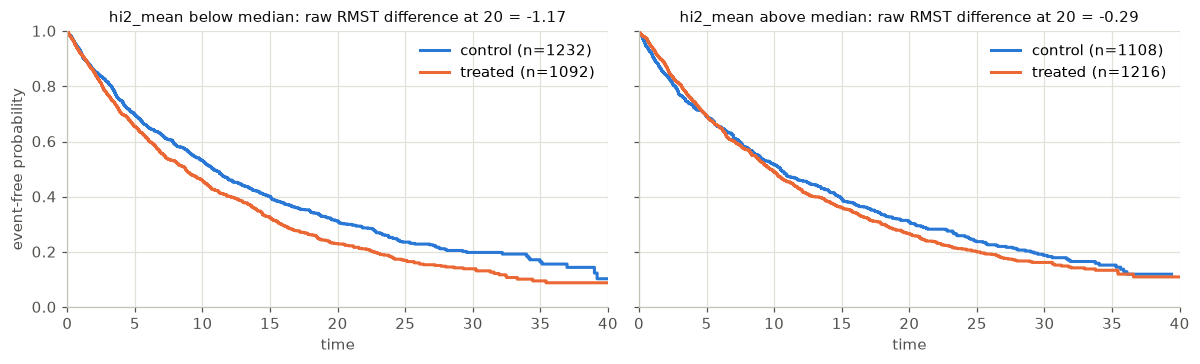

In [7]:
from lifelines import CoxPHFitter

Z = StandardScaler().fit_transform(X_all[known])
base = pd.DataFrame({"T": df.duration[known].values, "E": df.event[known].values, "w": w})
rows = []
for j, f in enumerate(FEATURE_NAMES):
    d_ = base.copy(); d_["x"] = Z[:, j]; d_["wx"] = d_["w"] * d_["x"]
    s = CoxPHFitter(penalizer=0.01).fit(d_, "T", "E").summary.loc["wx"]
    rows.append({"feature": f, "interaction_coef": s["coef"], "p": s["p"]})
inter = pd.DataFrame(rows).sort_values("p")
print("treatment x feature interaction in a Cox model, one feature at a time (30 tests, so the Bonferroni threshold is 0.0017):")
print(inter.head(6).round(4).to_string(index=False))

strongest = inter.feature.iloc[0]
x = X_all[known][:, FEATURE_NAMES.index(strongest)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (name, m) in zip(axes, [(f"{strongest} below median", x <= np.median(x)), (f"{strongest} above median", x > np.median(x))]):
    for arm, arm_name, c in [(0, "control", BLUE), (1, "treated", ORANGE)]:
        mm = m & (w == arm)
        ut, S = M.kaplan_meier(base["T"][mm], base["E"][mm])
        ax.step(np.r_[0, ut], np.r_[1, S], where="post", color=c, label=f"{arm_name} (n={mm.sum()})")
    diff = M.ate_rmst(base["T"][m].values, base["E"][m].values, w[m], 20.0)
    ax.set_title(f"{name}: raw RMST difference at 20 = {diff:+.2f}", fontsize=10)
    ax.set_xlim(0, 40); ax.set_ylim(0, 1); ax.set_xlabel("time"); ax.legend()
axes[0].set_ylabel("event-free probability")
plt.tight_layout(); plt.show()

## 2. Build the model

The code for this section is in `src/treatment_effect/` (features, learners, metrics, splits) and `experiments/run_candidates.py` (the sweep). The notebook calls the same code, so what you see here is what ran. Results are loaded from `experiments/results/` by default; set `RUN_EXPERIMENTS = True` below to recompute everything.

### Features

Every patient becomes 30 numbers. For each of the four dimensions: mean, standard deviation, min and max over the vectors. Then the number of vectors, the missing rates of dimensions 2 and 3 and how often both are missing together. For dimensions 2 and 3: the share of vectors in the high mode (above 2.4), the mean inside the high mode, the mean inside the low mode, and the share of vectors that are high in either or in both dimensions. Finally the within-patient correlation of dimensions 0 and 1 and the mean norm of the (0, 1) part. Nothing here depends on the order of the vectors.

In [8]:
from treatment_effect.features import FEATURE_NAMES
print(f"{len(FEATURE_NAMES)} features per patient:")
print(", ".join(FEATURE_NAMES))

30 features per patient:
d0_mean, d0_std, d0_min, d0_max, d1_mean, d1_std, d1_min, d1_max, d2_mean, d2_std, d2_min, d2_max, d3_mean, d3_std, d3_min, d3_max, n_vectors, miss_d2, miss_d3, miss_both, hi2_frac, hi2_mean, hi3_frac, hi3_mean, lo2_mean, lo3_mean, hi_any_frac, hi_both_frac, d0_d1_corr, norm01_mean


### Candidates

Twenty-two learners, built from one registry so that the sweep, the notebook and the training script agree on what each name means. The first six only need survival models. The meta-learners work on the restricted outcome $\min(T, 20)$ with IPCW weights from a Cox censoring model; the two `_kmpv` rows use Kaplan-Meier pseudo-values instead, which is what I did first before the censoring check. The two `setnet` rows are the network on the raw vectors.

In [9]:
from treatment_effect import models as Mo

descriptions = {
    "constant_ate": "same effect for everyone: doubly robust ATE (propensity + outcome models + IPCW)",
    "cox_s_learner": "Cox PH, treatment as one covariate; effect varies only through baseline risk",
    "cox_interactions": "Cox PH with treatment x feature interactions (ridge penalty)",
    "t_learner_cox": "one Cox model per arm, RMST difference",
    "t_learner_gbsa": "one gradient boosted survival model per arm",
    "t_learner_rsf": "one random survival forest per arm",
    "s_learner_gbm": "boosted trees on [features, treatment], IPCW-weighted restricted outcome",
    "s_learner_ridge_interactions": "ridge on [features, treatment, features x treatment], IPCW",
    "t_learner_gbm": "boosted trees per arm on the IPCW restricted outcome",
    "t_learner_ridge": "ridge per arm on the IPCW restricted outcome",
    "x_learner_gbm": "X-learner (imputed effects per arm, propensity-weighted blend), boosted trees",
    "dr_learner_ridge": "DR-learner: cross-fitted propensity + outcome models -> pseudo-outcome -> ridge",
    "dr_learner_gbm_small": "DR-learner with shallow boosted trees for the effect",
    "dr_learner_gbm": "DR-learner with deeper boosted trees for the effect",
    "dr_learner_rf": "DR-learner with a random forest for the effect",
    "dr_learner_ridge_gbsanuisance": "DR-learner whose outcome models are boosted survival models",
    "r_learner_ridge": "R-learner (residual-on-residual), ridge effect",
    "r_learner_gbm_small": "R-learner, shallow boosted trees effect",
    "dr_learner_ridge_kmpv": "DR-learner on Kaplan-Meier pseudo-values (ignores covariate-dependent censoring)",
    "t_learner_gbm_kmpv": "T-learner on Kaplan-Meier pseudo-values (same caveat)",
    "setnet": "DeepSets encoder on the raw vectors, two discrete-time survival heads",
    "setnet_plus_features": "same network, hand-made features concatenated to the pooled set representation",
}
assert set(descriptions) == set(Mo.CANDIDATE_NAMES)
for name in Mo.CANDIDATE_NAMES:
    print(f"{name:32s} {descriptions[name]}")

constant_ate                     same effect for everyone: doubly robust ATE (propensity + outcome models + IPCW)
cox_s_learner                    Cox PH, treatment as one covariate; effect varies only through baseline risk
cox_interactions                 Cox PH with treatment x feature interactions (ridge penalty)
t_learner_cox                    one Cox model per arm, RMST difference
t_learner_gbsa                   one gradient boosted survival model per arm
t_learner_rsf                    one random survival forest per arm
s_learner_gbm                    boosted trees on [features, treatment], IPCW-weighted restricted outcome
s_learner_ridge_interactions     ridge on [features, treatment, features x treatment], IPCW
t_learner_gbm                    boosted trees per arm on the IPCW restricted outcome
t_learner_ridge                  ridge per arm on the IPCW restricted outcome
x_learner_gbm                    X-learner (imputed effects per arm, propensity-weighted blend), booste

### Protocol

Five stratified folds on the development split. On each fold the same nuisance models are fit on the training part: a boosted-tree propensity model, a Cox censoring model, and one IPCW-weighted boosted-tree outcome model per arm. From these, every validation patient gets a doubly robust pseudo-outcome $\varphi_i$ and arm weights (inverse propensity times inverse censoring). Each candidate is then scored on the validation part with:

- `dr_loss`: mean of $(\hat\tau(x_i) - \varphi_i)^2$. I report it as the fold-wise difference to the constant baseline, with the standard error over the five folds, because the raw number is almost entirely outcome noise (around 600) and the differences between models are a few units.
- `autoc_ipw`: the rank-weighted average treatment effect with those weights. Zero means ranking patients by the prediction is no better than ranking them at random.
- `cindex`: for candidates that predict per-arm outcomes, Harrell's C of each arm's RMST prediction against that arm's observed times.

The folds, seeds and hyperparameters are fixed in the code; nothing was tuned on the validation folds beyond what is shown. One caveat I want on the record: the DR-loss is built from the same kind of nuisance models the DR-learners use, which could flatter them a little. The AUTOC does not use the outcome models at all, and it tells the same story.

In [10]:
import subprocess
sys.path.insert(0, "experiments")
from analysis import load_results, paired_table, ensemble_scores, agreement

FINAL = "dr_learner_ridge"   # the model picked at the end of this section, named here so the figures can highlight it

RUN_EXPERIMENTS = False   # True re-runs the whole sweep (about 25 minutes on a laptop); False loads the saved results
if RUN_EXPERIMENTS:
    subprocess.run([sys.executable, "experiments/run_candidates.py"], check=True)

res, summary = load_results()
table = paired_table(res)
print(f"{res.fold.nunique()} folds x {res.candidate.nunique()} candidates. dr_loss_vs_constant: mean fold-wise difference to the constant baseline (negative = better), with its standard error.")
table.round(3)

5 folds x 22 candidates. dr_loss_vs_constant: mean fold-wise difference to the constant baseline (negative = better), with its standard error.


,dr_loss_vs_constant,se,folds_better,autoc,autoc_se,qini,cindex_control,cindex_treated,effect_sd,effect_mean,seconds
candidate,,,,,,,,,,,
dr_learner_ridge,-3.194,0.883,5,1.908,0.412,0.609,NaN,NaN,1.784,0.834,14.72
r_learner_ridge,-2.722,0.430,5,1.826,0.376,0.590,NaN,NaN,1.426,0.570,8.86
dr_learner_ridge_gbsanuisance,-2.436,0.485,5,1.610,0.363,0.539,NaN,NaN,1.198,0.388,41.44
s_learner_gbm,-2.176,0.633,5,1.643,0.268,0.448,0.564,0.517,0.710,0.455,3.90
s_learner_ridge_interactions,-2.067,0.438,5,1.624,0.337,0.506,0.563,0.535,1.048,0.249,0.76
dr_learner_gbm_small,-1.643,1.409,3,1.786,0.326,0.555,NaN,NaN,3.182,0.881,15.62
r_learner_gbm_small,-1.522,1.927,4,1.569,0.239,0.442,NaN,NaN,2.854,0.880,9.80
x_learner_gbm,-1.445,2.814,3,1.340,0.441,0.447,0.546,0.515,2.982,1.053,6.14
dr_learner_rf,-1.435,2.453,2,1.664,0.375,0.519,NaN,NaN,3.322,0.852,16.80


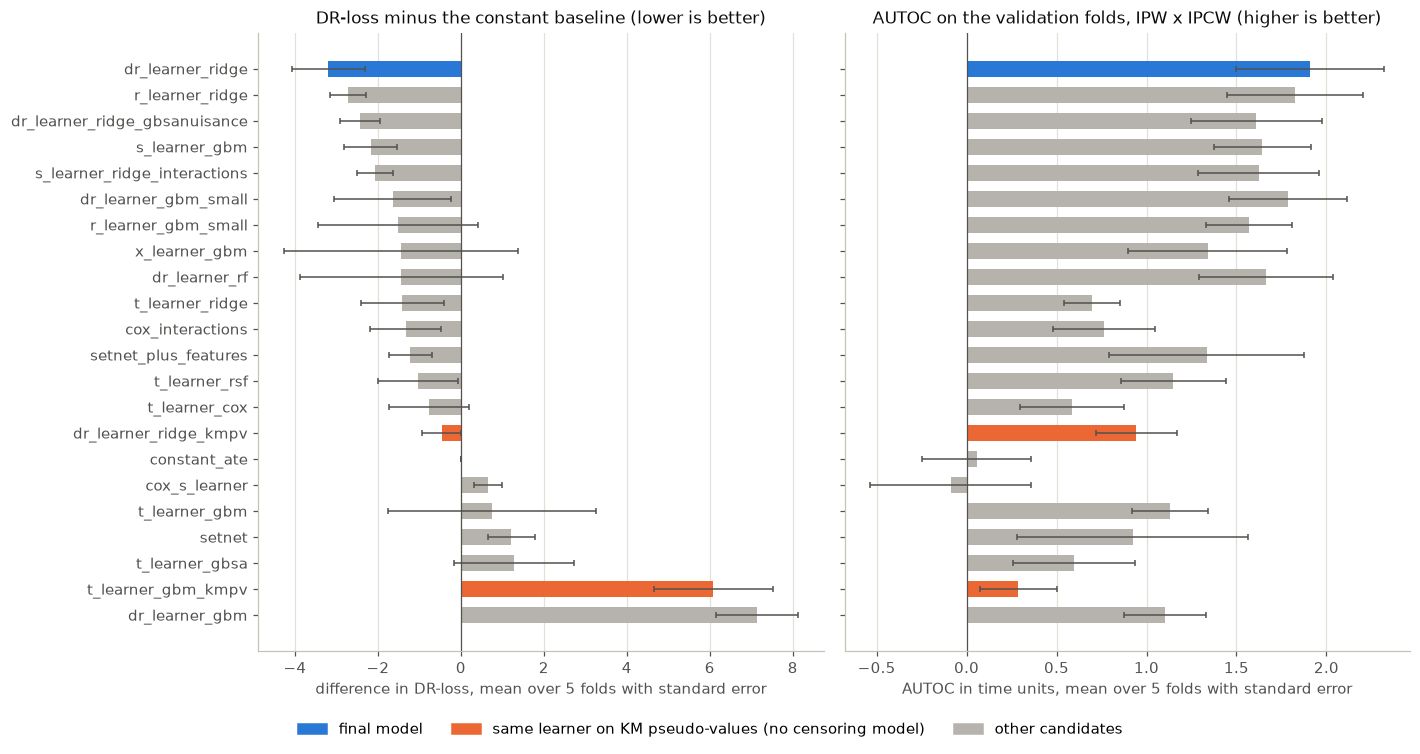

In [11]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 2, figsize=(13, 6.8), sharey=True)
order = table.index[::-1]
colors = [BLUE if n == FINAL else ORANGE if n.endswith("_kmpv") else DIM for n in order]
axes[0].barh(order, table.loc[order, "dr_loss_vs_constant"], xerr=table.loc[order, "se"], height=0.62, color=colors,
             error_kw={"ecolor": INK, "elinewidth": 1, "capsize": 2})
axes[0].axvline(0, color=INK, lw=0.8); axes[0].set_title("DR-loss minus the constant baseline (lower is better)")
axes[0].set_xlabel("difference in DR-loss, mean over 5 folds with standard error")
axes[1].barh(order, table.loc[order, "autoc"], xerr=table.loc[order, "autoc_se"], height=0.62, color=colors,
             error_kw={"ecolor": INK, "elinewidth": 1, "capsize": 2})
axes[1].axvline(0, color=INK, lw=0.8); axes[1].set_title("AUTOC on the validation folds, IPW x IPCW (higher is better)")
axes[1].set_xlabel("AUTOC in time units, mean over 5 folds with standard error")
fig.legend(handles=[Patch(color=BLUE, label="final model"), Patch(color=ORANGE, label="same learner on KM pseudo-values (no censoring model)"),
                    Patch(color=DIM, label="other candidates")], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01))
for ax in axes:
    ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

### What the sweep says

Three things stand out.

1. **The simple, heavily regularised effect models win.** The DR-learner with a ridge effect model is the best candidate on both criteria: DR-loss 3.2 below the constant baseline (better on all 5 folds) and an AUTOC of 1.91 (standard error 0.41) against 0.06 for the constant. The R-learner with ridge is right behind it (2.7 below, 5 of 5 folds, AUTOC 1.83), and the two agree almost perfectly (correlation 0.98 between their out-of-fold predictions), which is reassuring because they get at the effect in different ways. The candidates that let boosted trees or a forest model the effect itself are, at best, no better than the constant within noise (1.4 to 1.6 below it, with standard errors of 1.4 to 2.8 and only 2 or 3 folds out of 5 in their favour) and the deeper ones are clearly worse (the T-learner on boosted survival trees 1.3 above the constant, the DR-learner with deeper trees 7 above). Their prediction spreads of 3 to 4.5 time units are noise being fitted: the effect that is actually there has a spread of roughly 1 to 1.5. With 3,700 patients and this much outcome noise, 30 ridge coefficients are about what the data can support.
2. **The censoring model matters more than I expected.** The same DR-learner on Kaplan-Meier pseudo-values (`dr_learner_ridge_kmpv`) drops from 3.2 below the constant to 0.5 below (3 folds out of 5), and from 1.91 to 0.94 on AUTOC, and the adjusted average effect moves from about zero to +0.8 time units. The T-learner on boosted trees goes from 0.8 above the constant to 6 above when the censoring model is taken away. Censoring here depends on the same features that predict the event, and on treatment itself (treated patients are followed longer). Ignoring that pulls the estimates back towards the raw, confounded picture.
3. **Survival models per arm do not translate into good effect estimates.** The T-learners and the Cox models sit between the constant and the ridge meta-learners (0.8 to 1.4 below the constant, with wide standard errors). They describe each arm's curve about as well as anything (C-index 0.55 to 0.56 for the outcome itself, which is roughly all the signal there is), but the difference of two independently fitted curves is mostly noise. The DeepSets network beats the constant only when the hand-made features are attached (1.2 below, 5 of 5 folds); without them it is worse than the constant, so the learned pooling did not find anything the summaries miss. One more small lesson: with pseudo-values the boosted-tree S-learner had predicted essentially no effect for anyone (the trees never split on treatment), which is the known failure mode of S-learners under regularisation; with the IPCW weights in place it does learn an effect and lands in the top six.

In [12]:
# the same folds, different seed, for the candidates that mattered
if RUN_EXPERIMENTS:
    subprocess.run([sys.executable, "experiments/run_candidates.py", "--seed", "1", "--tag", "seed1", "--only", ",".join(["dr_learner_ridge", "r_learner_ridge", "dr_learner_ridge_gbsanuisance", "s_learner_gbm", "s_learner_ridge_interactions", "setnet_plus_features"])], check=True)

res1, _ = load_results("seed1")
t1 = paired_table(res1)
side = pd.concat({"seed 0": table.loc[t1.index, ["dr_loss_vs_constant", "se", "autoc"]], "seed 1": t1[["dr_loss_vs_constant", "se", "autoc"]]}, axis=1)
side.round(3)

seed 0                            seed 1              
                              dr_loss_vs_constant     se  autoc dr_loss_vs_constant     se  autoc
candidate                                                                                        
dr_learner_ridge                           -3.194  0.883  1.908              -3.151  1.145  1.633
r_learner_ridge                            -2.722  0.430  1.826              -3.110  0.797  1.587
dr_learner_ridge_gbsanuisance              -2.436  0.485  1.610              -2.993  0.501  1.497
s_learner_ridge_interactions               -2.067  0.438  1.624              -2.458  1.056  1.692
s_learner_gbm                              -2.176  0.633  1.643              -2.301  0.697  1.984
setnet_plus_features                       -1.213  0.526  1.334              -2.051  0.425  1.465
constant_ate                                0.000  0.000  0.056               0.000  0.000 -0.017

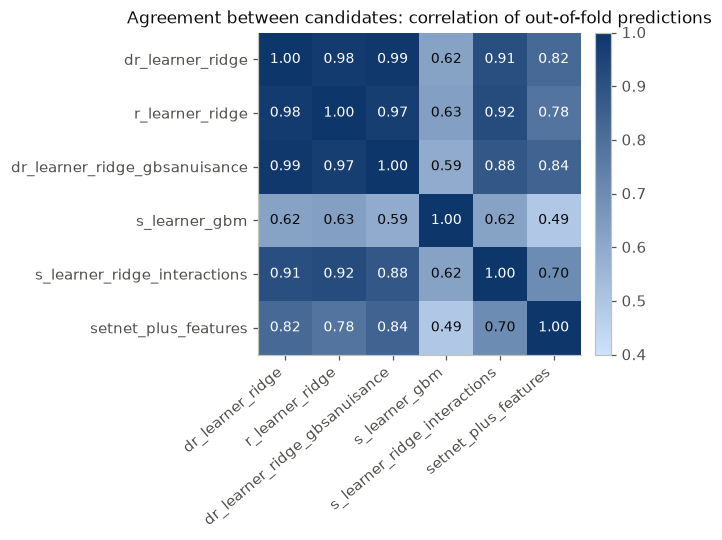

,ensemble,dr_loss_vs_constant,se,folds_better,autoc,autoc_se,effect_sd
0,dr_learner_ridge+r_learner_ridge,-3.030,0.636,5,1.894,0.398,1.650
1,dr_learner_ridge+s_learner_gbm,-3.278,0.379,5,1.998,0.350,1.191
2,dr_learner_ridge+dr_learner_ridge_gbsanuisance,-2.971,0.650,5,1.793,0.387,1.531
3,dr_learner_ridge+r_learner_ridge+s_learner_gbm...,-2.885,0.364,5,2.001,0.398,1.089


In [13]:
# does averaging the best few beat the best one? (scored from the out-of-fold predictions, same folds, same nuisances)
from matplotlib.colors import LinearSegmentedColormap
corr = agreement(["dr_learner_ridge", "r_learner_ridge", "dr_learner_ridge_gbsanuisance", "s_learner_gbm", "s_learner_ridge_interactions", "setnet_plus_features"])
fig, ax = plt.subplots(figsize=(6.4, 5))
cmap = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#0d366b"])
im = ax.imshow(corr.values, cmap=cmap, vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=40, ha="right"); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.75 else "#0b0b0b", fontsize=9)
ax.grid(False); ax.set_title("Agreement between candidates: correlation of out-of-fold predictions")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout(); plt.show()

ens = pd.concat([ensemble_scores(names) for names in [["dr_learner_ridge", "r_learner_ridge"], ["dr_learner_ridge", "s_learner_gbm"], ["dr_learner_ridge", "dr_learner_ridge_gbsanuisance"], ["dr_learner_ridge", "r_learner_ridge", "s_learner_gbm", "setnet_plus_features"]]], ignore_index=True)
ens.round(3)

### Second seed and ensembles

With a different fold assignment the same six candidates come out ahead of the constant again (four or five folds out of five each) and by similar margins: the DR-learner with ridge sits 3.2 below the constant on both seeds, the R-learner at 2.7 and 3.1, the DR-learner on boosted-survival nuisances at 2.4 and 3.0. The order of the top three holds, but the gaps between them are inside one standard error, and those three agree with each other at a correlation of 0.97 to 0.99 (the heatmap below), so this is one model wearing three hats, and the choice among them is not something the data can settle.

Averaging the DR-learner with the boosted S-learner (correlation only 0.62 between them, so there is real diversity) gives a DR-loss 3.3 below the constant against 3.2 for the DR-learner alone, a slightly higher AUTOC (2.00 against 1.91) and a smaller spread across folds. A little better, inside one standard error. Larger averages add nothing.

### The final model

`dr_learner_ridge`: the DR-learner with cross-fitted boosted-tree propensity and outcome models, a Cox censoring model for the IPCW weights, and ridge regression (penalty chosen by cross-validation) for the effect on the 30 features. I take it over the ensemble because the gain is inside the noise and a single ridge model is something a doctor can be shown: 30 coefficients, each saying which way a feature pushes the expected benefit. It fits in under 30 seconds and needs only scikit-learn at inference time. The R-learner would have been an equally defensible pick, and the ensemble with the S-learner is the obvious upgrade if more data ever makes its edge real.

## 3. Report

The final learner is fit on the development split (3,718 patients) and evaluated once on the 930 test patients it has never seen. The nuisance models used to score it (propensity, censoring, outcome) are also fit on the development split only. The checks are the ones used for selection, plus the calibration table, which is the closest thing there is to a direct test of the numbers themselves.

In [14]:
from treatment_effect.splits import labeled, dev_test_split
from run_candidates import fold_nuisances

HORIZON = 20.0
FINAL = "dr_learner_ridge"

data = labeled(records)
dev_idx, test_idx = dev_test_split(data)
dev = data.subset(np.isin(np.arange(len(data)), dev_idx))
test = data.subset(np.isin(np.arange(len(data)), test_idx))
X_dev, X_test = feature_matrix(dev.embeddings), feature_matrix(test.embeddings)
w_dev, t_dev, e_dev = dev.treatment.astype(int), dev.duration, dev.event
w_test, t_test, e_test = test.treatment.astype(int), test.duration, test.event
print(f"development split: {len(dev)} patients, test split: {len(test)} ({int(w_test.sum())} treated, {int(e_test.sum())} events)")

final = Mo.build_learner(FINAL, HORIZON).fit(X_dev, w_dev, t_dev, e_dev)
baseline = Mo.build_learner("constant_ate", HORIZON).fit(X_dev, w_dev, t_dev, e_dev)
tau_test = final.predict(X_test)
ate_dev = baseline.ate_

# nuisance models for the test split are fit on the development split only
nuis = fold_nuisances(X_dev, w_dev, t_dev, e_dev, X_test, w_test, t_test, e_test, HORIZON, seed=0)
print(f"adjusted average effect on the development split: {ate_dev:+.3f} (se {baseline.ate_se_:.3f}); mean prediction on test: {tau_test.mean():+.3f}, sd {tau_test.std():.3f}, share > 0: {(tau_test > 0).mean():.1%}")

development split: 3718 patients, test split: 930 (462 treated, 598 events)


adjusted average effect on the development split: +0.898 (se 0.362); mean prediction on test: +1.030, sd 1.689, share > 0: 74.9%


DR-loss, final model minus constant baseline: -1.894   95% bootstrap CI [-6.897, +2.886]
(the DR pseudo-outcome has a standard deviation of 21.6; the predictions have a spread of 1.69)

AUTOC (IPW x IPCW): +1.971   95% CI [+0.823, +3.063]   one-sided permutation p = 0.003
for scale, the AUTOC these predictions would reach if they were exactly right: +1.326
outcome model for arm 0 (nuisance, fit on the development split): C-index on test 0.539
outcome model for arm 1 (nuisance, fit on the development split): C-index on test 0.551

IPW x IPCW weights: 684 of 930 test patients have an observed restricted outcome; max weight = 9.9x the mean; effective sample size 470 (69% of 684)

observed (IPW x IPCW) vs predicted effect by predicted-benefit quintile, calibration slope = 1.05:
 bin   n  pred_mean  obs_effect  ci_low  ci_high
   1 186     -1.467      -0.344  -2.594    1.930
   2 186      0.221       0.910  -1.732    3.590
   3 186      1.202       0.761  -2.143    3.328
   4 186      1.991

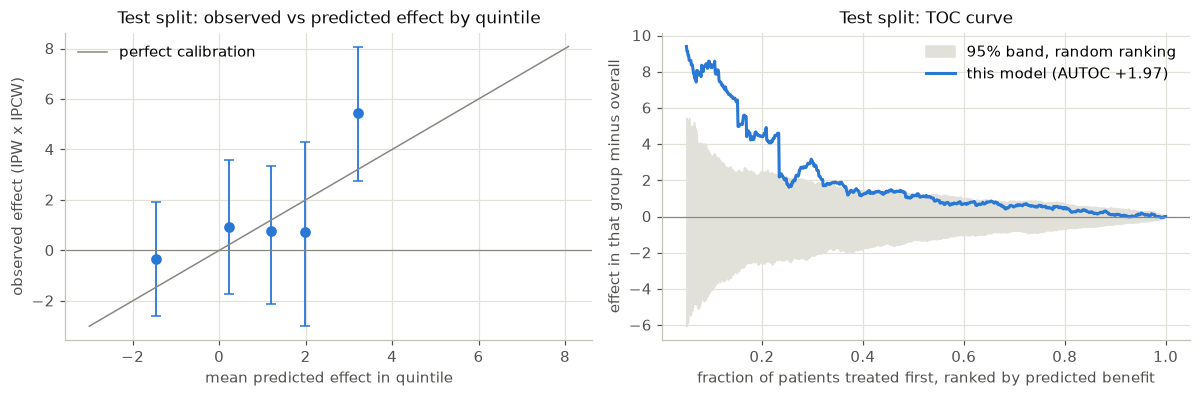

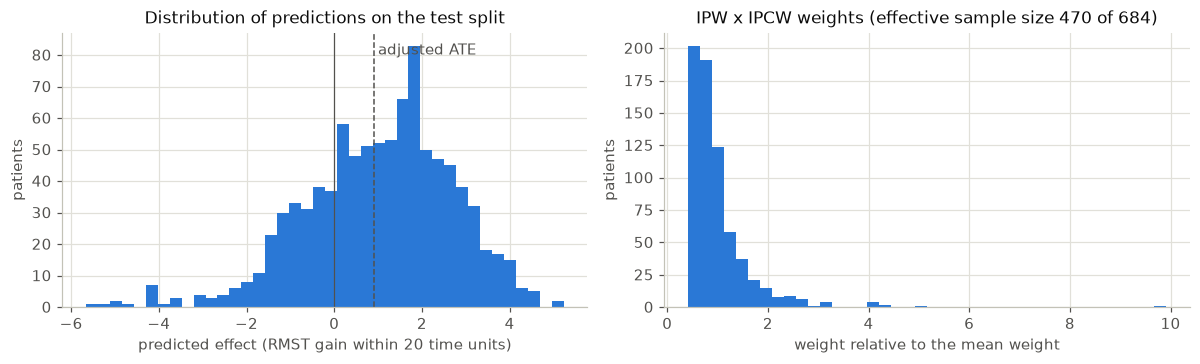

In [15]:
rng = np.random.default_rng(0)
phi = nuis["phi"]
d_loss = (tau_test - phi) ** 2 - (ate_dev - phi) ** 2
boots = np.array([d_loss[rng.integers(0, len(d_loss), len(d_loss))].mean() for _ in range(2000)])
print(f"DR-loss, final model minus constant baseline: {d_loss.mean():+.3f}   95% bootstrap CI [{np.percentile(boots, 2.5):+.3f}, {np.percentile(boots, 97.5):+.3f}]")
print(f"(the DR pseudo-outcome has a standard deviation of {phi.std():.1f}; the predictions have a spread of {tau_test.std():.2f})")

res_autoc = M.autoc_weighted_with_ci(tau_test, nuis["y"], nuis["a"], nuis["b"], n_boot=300, n_perm=300, seed=0)
print(f"\nAUTOC (IPW x IPCW): {res_autoc['autoc']:+.3f}   95% CI [{res_autoc['ci_low']:+.3f}, {res_autoc['ci_high']:+.3f}]   one-sided permutation p = {res_autoc['perm_p_value']:.3f}")
order = np.argsort(-tau_test)
ideal = float(np.mean([tau_test[order[:k]].mean() - tau_test.mean() for k in np.maximum(2, np.ceil(np.linspace(0.05, 1, 40) * len(tau_test)).astype(int))]))
print(f"for scale, the AUTOC these predictions would reach if they were exactly right: {ideal:+.3f}")
for arm in (0, 1):
    m = w_test == arm
    print(f"outcome model for arm {arm} (nuisance, fit on the development split): C-index on test {M.concordance(t_test[m], e_test[m], -nuis['mu' + str(arm)][m]):.3f}")

weights = nuis["a"] + nuis["b"]          # each patient has one arm, so one of the two is zero
obs_w = weights[weights > 0]
ess = obs_w.sum() ** 2 / np.sum(obs_w ** 2)
print(f"\nIPW x IPCW weights: {len(obs_w)} of {len(weights)} test patients have an observed restricted outcome; "
      f"max weight = {obs_w.max() / obs_w.mean():.1f}x the mean; effective sample size {ess:.0f} ({ess / len(obs_w):.0%} of {len(obs_w)})")

calib, slope = M.calibration_by_bins_weighted(tau_test, nuis["y"], nuis["a"], nuis["b"], n_bins=5, n_boot=300, seed=0)
print(f"\nobserved (IPW x IPCW) vs predicted effect by predicted-benefit quintile, calibration slope = {slope:.2f}:")
print(calib.round(3).to_string(index=False))

# TOC curve of the model against the band produced by random orderings
q, toc = M.toc_curve_weighted(tau_test, nuis["y"], nuis["a"], nuis["b"])
perm_toc = np.array([M.toc_curve_weighted(rng.permutation(tau_test), nuis["y"], nuis["a"], nuis["b"])[1] for _ in range(300)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7))
ax = axes[0]
ax.errorbar(calib.pred_mean, calib.obs_effect, yerr=[calib.obs_effect - calib.ci_low, calib.ci_high - calib.obs_effect],
            fmt="o", ms=6, capsize=3, color=BLUE, ecolor=BLUE, elinewidth=1.2)
lim = [min(calib.pred_mean.min(), calib.ci_low.min()), max(calib.pred_mean.max(), calib.ci_high.max())]
ax.plot(lim, lim, color=MUTED, lw=1, label="perfect calibration"); ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel("mean predicted effect in quintile"); ax.set_ylabel("observed effect (IPW x IPCW)")
ax.set_title("Test split: observed vs predicted effect by quintile"); ax.legend(loc="upper left")
ax = axes[1]
ax.fill_between(q, np.percentile(perm_toc, 2.5, axis=0), np.percentile(perm_toc, 97.5, axis=0), color=GRID, label="95% band, random ranking")
ax.plot(q, toc, color=BLUE, label=f"this model (AUTOC {res_autoc['autoc']:+.2f})"); ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel("fraction of patients treated first, ranked by predicted benefit"); ax.set_ylabel("effect in that group minus overall")
ax.set_title("Test split: TOC curve"); ax.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
ax.hist(tau_test, bins=40, color=BLUE); ax.axvline(0, color=INK, lw=0.8)
ax.axvline(ate_dev, color=INK, ls="--", lw=1); ax.text(ate_dev + 0.1, ax.get_ylim()[1] * 0.92, "adjusted ATE", color=INK)
ax.set_xlabel("predicted effect (RMST gain within 20 time units)"); ax.set_ylabel("patients"); ax.set_title("Distribution of predictions on the test split")
ax = axes[1]
ax.hist(obs_w / obs_w.mean(), bins=40, color=BLUE)
ax.set_xlabel("weight relative to the mean weight"); ax.set_ylabel("patients"); ax.set_title(f"IPW x IPCW weights (effective sample size {ess:.0f} of {len(obs_w)})")
plt.tight_layout(); plt.show()

                       rule  treated_share  expected_event_free_time  ci_low  ci_high
               treat nobody          0.000                    10.000   8.983   11.055
            treat everybody          1.000                    11.021  10.180   11.850
treat if the model says > 0          0.749                    11.083  10.369   11.896

gain of the model's rule over the better uniform rule: +0.062   95% CI [-0.592, +0.662]   (paired bootstrap)


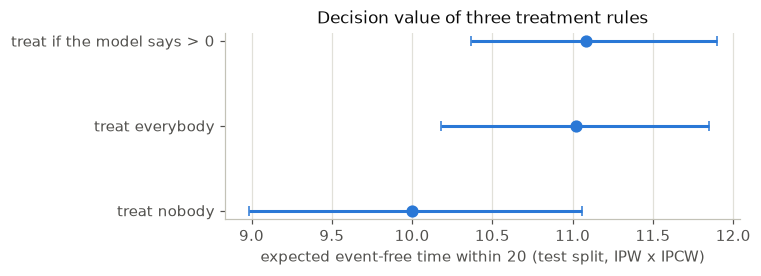

In [16]:
# decision value: expected event-free time within 20 if treatment followed each rule (IPW x IPCW, Hajek-weighted, on the test split)
def policy_value(treat, y, a, b):
    wgt = np.where(treat, a, b)
    return np.sum(wgt * y) / np.sum(wgt)

rules = {"treat nobody": np.zeros(len(tau_test), bool), "treat everybody": np.ones(len(tau_test), bool), "treat if the model says > 0": tau_test > 0}
n = len(tau_test)
boot_idx = [rng.integers(0, n, n) for _ in range(500)]
rows = []
for name, rule in rules.items():
    v = policy_value(rule, nuis["y"], nuis["a"], nuis["b"])
    bs = np.array([policy_value(rule[i], nuis["y"][i], nuis["a"][i], nuis["b"][i]) for i in boot_idx])
    rows.append({"rule": name, "treated_share": rule.mean(), "expected_event_free_time": v, "ci_low": np.percentile(bs, 2.5), "ci_high": np.percentile(bs, 97.5), "_bs": bs})
val = pd.DataFrame(rows)
gain = val.loc[2, "_bs"] - np.maximum(val.loc[0, "_bs"], val.loc[1, "_bs"])
print(val.drop(columns="_bs").round(3).to_string(index=False))
print(f"\ngain of the model's rule over the better uniform rule: {val.expected_event_free_time[2] - val.expected_event_free_time[:2].max():+.3f}   "
      f"95% CI [{np.percentile(gain, 2.5):+.3f}, {np.percentile(gain, 97.5):+.3f}]   (paired bootstrap)")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.errorbar(val.expected_event_free_time, val.rule, xerr=[val.expected_event_free_time - val.ci_low, val.ci_high - val.expected_event_free_time],
            fmt="o", ms=7, capsize=3, color=BLUE, ecolor=BLUE)
ax.grid(False, axis="y"); ax.set_xlabel("expected event-free time within 20 (test split, IPW x IPCW)")
ax.set_title("Decision value of three treatment rules")
plt.tight_layout(); plt.show()

ridge alpha chosen by cross-validation: 5623.4 on a grid up to 1e4; a grid up to 1e6 picks 5623.4, so the optimum is interior


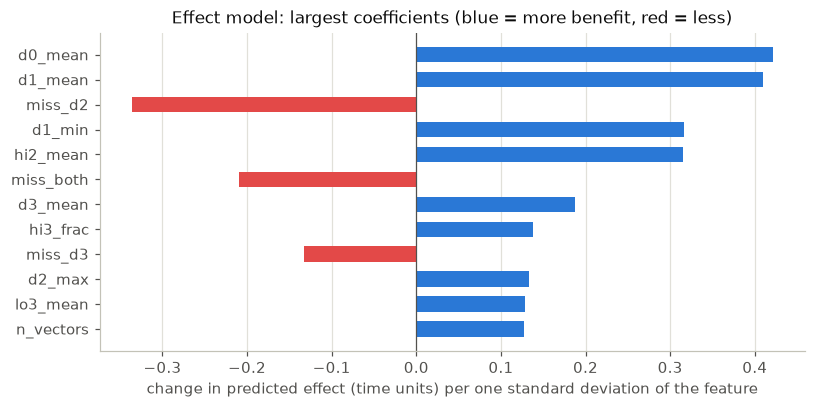

In [17]:
# what the effect model looks at: standardized ridge coefficients of the final DR-learner
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
effect_model = final.model_
if hasattr(effect_model, "steps") and hasattr(effect_model[-1], "coef_"):
    wide = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 6, 33))).fit(X_dev, final.phi_)
    print(f"ridge alpha chosen by cross-validation: {effect_model[-1].alpha_:.1f} on a grid up to 1e4; a grid up to 1e6 picks {wide[-1].alpha_:.1f}, so the optimum is interior")
    coefs = pd.Series(effect_model[-1].coef_, index=FEATURE_NAMES)
    top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    ax.barh(top.index[::-1], top.values[::-1], height=0.62, color=[BLUE if v > 0 else RED for v in top.values[::-1]])
    ax.axvline(0, color=INK, lw=0.8); ax.grid(False, axis="y")
    ax.set_xlabel("change in predicted effect (time units) per one standard deviation of the feature")
    ax.set_title("Effect model: largest coefficients (blue = more benefit, red = less)")
    plt.tight_layout(); plt.show()

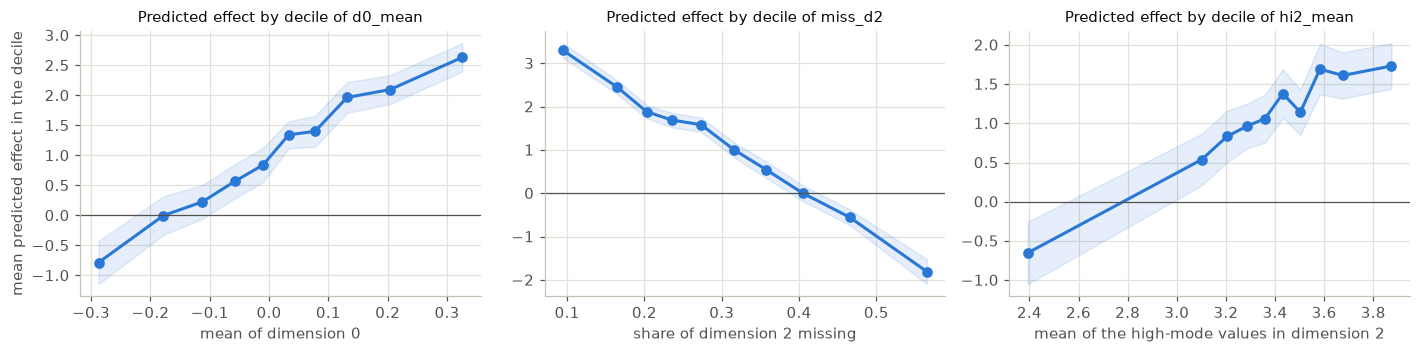

In [18]:
# the same relationships seen directly in the predictions: mean predicted effect by decile of the three strongest features
drivers = ["d0_mean", "miss_d2", "hi2_mean"]
labels = {"d0_mean": "mean of dimension 0", "miss_d2": "share of dimension 2 missing", "hi2_mean": "mean of the high-mode values in dimension 2"}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, f in zip(axes, drivers):
    x = X_test[:, FEATURE_NAMES.index(f)]
    dec = pd.qcut(x, 10, labels=False, duplicates="drop")
    g = pd.DataFrame({"x": x, "tau": tau_test, "dec": dec}).groupby("dec").agg(
        x=("x", "mean"), tau=("tau", "mean"), se=("tau", lambda v: v.std() / np.sqrt(len(v))))
    ax.fill_between(g.x, g.tau - 1.96 * g.se, g.tau + 1.96 * g.se, color=BLUE, alpha=0.12)
    ax.plot(g.x, g.tau, "o-", color=BLUE, ms=6)
    ax.axhline(0, color=INK, lw=0.8)
    ax.set_xlabel(labels[f]); ax.set_title(f"Predicted effect by decile of {f}", fontsize=10)
axes[0].set_ylabel("mean predicted effect in the decile")
plt.tight_layout(); plt.show()

In [19]:
# sensitivity to the horizon: the same learner at H = 10
final_h10 = Mo.build_learner(FINAL, 10.0).fit(X_dev, w_dev, t_dev, e_dev)
tau_h10 = final_h10.predict(X_test)
base_h10 = Mo.build_learner("constant_ate", 10.0).fit(X_dev, w_dev, t_dev, e_dev)
print(f"H = 10: adjusted ATE {base_h10.ate_:+.3f}, prediction sd {tau_h10.std():.3f}, share > 0 {(tau_h10 > 0).mean():.1%}")
print(f"correlation between the H = 10 and H = 20 predictions on the test split: {np.corrcoef(tau_h10, tau_test)[0, 1]:.3f}")
print(f"rank agreement on who is in the top 20% predicted benefit: {np.mean(np.isin(np.argsort(-tau_h10)[:len(tau_h10)//5], np.argsort(-tau_test)[:len(tau_test)//5])):.0%}")

H = 10: adjusted ATE +0.438, prediction sd 0.493, share > 0 83.2%
correlation between the H = 10 and H = 20 predictions on the test split: 0.916
rank agreement on who is in the top 20% predicted benefit: 74%


### What the test split says

- **The ranking is real.** AUTOC +1.97 with a bootstrap interval of [+0.82, +3.06] and a one-sided permutation p-value of 0.003: ordering patients by the prediction finds the patients who benefit far better than chance. The TOC curve sits above the band that random orderings produce along its whole length, not just at the top. For scale, if the predictions were exactly right the same ranking would score +1.32 (the yardstick the section 4 cell prints). The achieved value is above that, which can only happen if the real effects are more spread out than the predictions: the heavy ridge penalty compresses the extremes, so the model is too modest about its most and least promising patients. Not a problem for ranking, but worth knowing when the numbers are quoted.
- **The magnitudes are roughly right on average.** Observed against predicted effect by quintile has a slope of 1.05. The highest-benefit quintile shows an observed +5.4 time units [+2.7, +8.1] against a predicted +3.2; the lowest quintile an observed −0.3 [−2.6, +1.9] against a predicted −1.5. The middle three quintiles are indistinguishable from each other, with wide intervals: 186 patients per bin is not many once a quarter of them are censored before the horizon. So the model is sharp about who benefits a lot, and honest but uncertain about who does not. The bottom of the distribution looks more like "little or no benefit" than "harm", and that is how I would phrase it to a doctor rather than quoting the negative numbers.
- **The DR-loss cannot tell the model from a constant on 930 patients** (−1.9, interval [−6.9, +2.9]). That is a sample-size statement, not a contradiction: the DR pseudo-outcome has a standard deviation of 22 and the predictions a spread of 1.7, so an improvement of a unit or two needs thousands of patients to show. This is why selection used five folds and paired differences, and why the trial, with ten times the patients, is the evaluation that counts.
- The adjusted average effect is +0.9 time units (standard error 0.36) within 20, and three quarters of patients are predicted to benefit. The weights behind these numbers are moderately spread, as inverse-probability weights usually are: the largest is about ten times the mean, and the effective sample size is 470 of the 684 test patients whose restricted outcome is observed (69%). Nothing pathological, but it is why the intervals are as wide as they are. The effect model's largest coefficients are the means of dimensions 0 and 1 (positive), the missing rate of dimension 2 (negative) and the level of the high-mode vectors in dimension 2 (positive); the decile plots show the same three relationships directly in the predictions, which is the kind of picture I would put in front of a doctor. The ridge penalty chosen by cross-validation is very large (alpha about 5,600 on standardised features), the data saying once more that only a few coarse directions carry effect signal.
- **What it is worth in time.** The decision-value check asks the doctor's question directly: how much event-free time within 20 does the average patient get if treatment follows each rule? On the test split, treating everybody and treating nobody come out almost level (the average effect is small), and treating only the patients the model flags (three quarters of them) comes out level with treating everybody: 11.08 against 11.02 time units, a gain of +0.06 with an interval of [−0.59, +0.66]. That is what it should look like when the average effect is about +1 and only a quarter of patients are predicted at or below zero: the value of withholding treatment from that quarter is small by construction, and 930 patients cannot resolve it. The same number on the trial, with ten times the patients and no weighting, is the one to watch.
- Moving the horizon to H = 10 changes the numbers (average effect +0.44, spread 0.49) but hardly the ranking (correlation 0.92 with the H = 20 predictions, 74% overlap in the top 20%). The horizon is a presentation choice more than a modelling one here.

### Stronger or weaker than expected?

Stronger on ranking, weaker on raw outcome prediction. I expected the outcome models to be poor and they are: C-index 0.54 to 0.55 on the test split, a hair above the 0.5 of a coin flip, which matches the warning in the task. I did not expect the effect ranking to come through as clearly as it does on top of such a weak outcome signal; a permutation p of 0.003 on a 930-patient split where a quarter of the patients are censored before the horizon is more than I would have bet on. The honest reading is that the treatment effect is driven by a handful of coarse features (the overall levels of dimensions 0, 1 and 2, and the missingness pattern), so a linear effect model on decent summaries gets most of what there is, while the outcome itself carries a lot of irreducible noise. I was wrong about two things along the way: the pseudo-value shortcut (censoring dependence costs a lot here) and the set network, which never beat the summaries.

### What I would do with a few more days

- Tune the regularisation path and the nuisance models with nested cross-validation instead of hand-picked settings, and bootstrap the whole pipeline so each patient gets an interval ("+2 ± 3") rather than a bare number.
- Swap the Cox censoring model for a boosted survival model of censoring and check that the IPCW weights, and the predictions, barely move. The whole analysis leans on that model.
- Add the few features ridge cannot build itself: interactions between the missingness pattern and the high-mode summaries, and a richer description of the high-mode vectors (how many, how extreme, in which dimension).
- Repeat the selection with a different 80/20 cut, to make sure the ranking of candidates is not an artefact of one split.
- Use the trial once its outcomes are in: a randomized trial gives unbiased subgroup effects, so recalibrating the score's magnitudes on it is legitimate, and it allows reporting the model's decision value, the extra event-free time gained if treatment followed the model's sign instead of going to everyone.

### Longer-term directions

- Learn the representation with the causal target in mind: models that share a representation across arms while penalising its dependence on treatment (balancing regularisers), trained on far more than 5,000 patients. The network here lost to the summaries because of sample size, not because the idea is wrong.
- Treat trials as training data, not only as tests. Combining observational data (many patients, confounded) with trial data (randomised, few patients) through a shared effect function plus a bias term for the observational part is the natural next design.
- Go from a point estimate of the effect to a decision policy with uncertainty, including the cost of the treatment and the harm it can do, and evaluate policies prospectively rather than on retrospective data.
- Find out what is behind the missing treatment records and the informative missingness in the embeddings. If missingness reflects how data were collected at different sites or times, the "same kind of patients" assumption deserves a closer look before any deployment.
- Competing risks and time-varying treatment: real patients die of other causes, and treatment is rarely a single decision at diagnosis.

## 4. External evaluation

The final learner is refit on all 4,648 patients with a known treatment and scores the 10,000 trial patients. `predictions/inference_predictions.csv` (and the same in `.json`) has one row per patient: `predicted_effect` is the expected event-free time gained by treating within the next 20 time units, positive meaning treatment is expected to help. The patients with an unknown treatment are scored like everyone else; they just cannot be used in the checks below.

{'learner': 'dr_learner_ridge', 'n_train': 4648, 'n_dropped_missing_treatment': 352, 'train_seconds': 15.7}



10000 predictions written to predictions/inference_predictions.csv and .json
mean predicted effect +0.765, sd 1.637, share predicted to benefit 70.0%


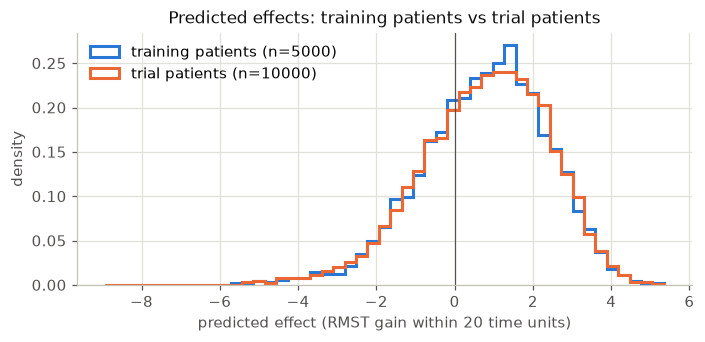

,patient_id,predicted_effect
0,p15000,0.418
1,p15001,-1.911
2,p15002,-0.453
3,p15003,0.343
4,p15004,-0.285


In [20]:
from treatment_effect.train import train

model = train("data/patient_records.json", "artifacts/model.joblib", learner=FINAL, horizon=HORIZON, seed=0)
print({k: model.meta[k] for k in ("learner", "n_train", "n_dropped_missing_treatment", "train_seconds")})

preds = model.predict(rct)
preds.to_csv("predictions/inference_predictions.csv", index=False)
preds.to_json("predictions/inference_predictions.json", orient="records", indent=2)
print(f"\n{len(preds)} predictions written to predictions/inference_predictions.csv and .json")
print(f"mean predicted effect {preds.predicted_effect.mean():+.3f}, sd {preds.predicted_effect.std():.3f}, share predicted to benefit {(preds.predicted_effect > 0).mean():.1%}")

# the trial patients should look like the training patients in the model's own output space too
train_preds = model.predict(records).predicted_effect
fig, ax = plt.subplots(figsize=(6.5, 3.2))
bins = np.linspace(min(train_preds.min(), preds.predicted_effect.min()), max(train_preds.max(), preds.predicted_effect.max()), 50)
ax.hist(train_preds, bins=bins, density=True, histtype="step", lw=2, color=BLUE, label=f"training patients (n={len(train_preds)})")
ax.hist(preds.predicted_effect, bins=bins, density=True, histtype="step", lw=2, color=ORANGE, label=f"trial patients (n={len(preds)})")
ax.axvline(0, color=INK, lw=0.8); ax.set_xlabel("predicted effect (RMST gain within 20 time units)"); ax.set_ylabel("density")
ax.set_title("Predicted effects: training patients vs trial patients"); ax.legend()
plt.tight_layout(); plt.show()
preds.head()

### Evaluation cell

The cell below is self-contained (its own imports and helpers). To evaluate against the real outcomes, change `OUTCOMES_PATH` and run it. It accepts the outcomes file in the same layout as `fake_inference_outcomes.json` or as a list of records, with or without a `treatment` column; if the column is missing it takes the arm from `inference_inputs.json`. Patients without a known arm, outcome or prediction are dropped and counted. On the fake outcomes everything should, and does, come out null.

patients in outcomes file: 10000; usable (known arm, outcome and prediction): 9264; treated 4596, events 4674
follow-up check at H=20: 2336 control and 2355 treated patients still at risk

average treatment effect in the trial (KM RMST difference at H=20): +0.006
mean predicted effect: +0.800   spread of predictions (sd): 1.629   share predicted to benefit: 71.0%



1) observed vs predicted effect by predicted-benefit 5-tile (1 = least predicted benefit):
 bin    n  n_treated  predicted  observed  ci_low  ci_high
   1 1853        957     -1.604     0.272  -0.249    0.752
   2 1853        949      0.018     0.229  -0.261    0.776
   3 1853        918      0.925    -0.107  -0.469    0.385
   4 1853        917      1.761    -0.186  -0.684    0.296
   5 1852        855      2.903    -0.180  -0.637    0.319
   calibration slope (observed on predicted, across bins): -0.12   [1 = magnitudes right, 0 = no relation]



2) AUTOC (rank-weighted average treatment effect, RMST units): -0.174   95% bootstrap CI [-0.369, +0.037]   one-sided permutation p = 0.955
   effect among the 20% with the highest predicted benefit: -0.180  vs  everyone: +0.006
   for scale: AUTOC if the predictions were exactly right = +1.282; this model reaches -14% of that

3) Cox interaction treatment x standardized score: coef +0.035 (HR 1.036), se 0.029, p = 0.2341   [negative = higher predicted benefit, bigger hazard reduction when treated]



4) decision value: expected event-free time within 20 under each rule
   treat nobody                 17.227   95% CI [17.096, 17.384]   (treats 0% of patients)
   treat everybody              17.232   95% CI [17.088, 17.376]   (treats 100% of patients)
   treat if the model says > 0  17.183   95% CI [17.024, 17.352]   (treats 71% of patients)
   gain of the model's rule over the better uniform rule: -0.050   95% CI [-0.223, +0.035]


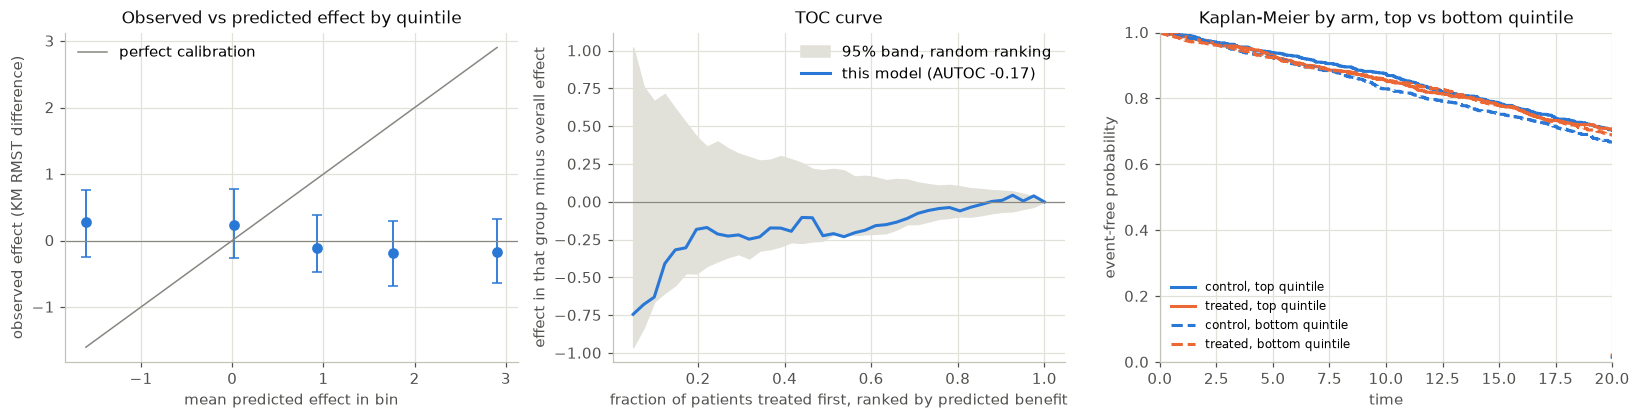

In [21]:
# ============================================================================
# External evaluation on the randomized trial. This cell is self-contained:
# change OUTCOMES_PATH to the real outcomes file and run it.
# ============================================================================
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PREDICTIONS_PATH = "predictions/inference_predictions.csv"  # written in the cell above
OUTCOMES_PATH = "data/fake_inference_outcomes.json"         # <- replace with the real outcomes
INPUTS_PATH = "data/inference_inputs.json"                   # only used to look up each patient's arm
HORIZON = 20.0                                               # same horizon the model was trained for


def _columns_to_frame(obj):
    """Accept the pandas 'columns' layout or a list of records."""
    if isinstance(obj, dict) and isinstance(obj.get("patient_id"), dict):
        keys = sorted(obj["patient_id"], key=lambda k: int(k) if str(k).isdigit() else str(k))
        return pd.DataFrame({c: [obj[c][k] for k in keys] for c in obj})
    return pd.DataFrame(obj)


def _load_trial(outcomes_path, inputs_path, predictions_path):
    with open(outcomes_path) as f:
        out = _columns_to_frame(json.load(f))
    out["patient_id"] = out["patient_id"].astype(str)
    if "treatment" not in out.columns:
        with open(inputs_path) as f:
            inp = json.load(f)
        trt = _columns_to_frame({"patient_id": inp["patient_id"], "treatment": inp["treatment"]})
        trt["patient_id"] = trt["patient_id"].astype(str)
        out = out.merge(trt, on="patient_id", how="left")
    pred = pd.read_csv(predictions_path, dtype={"patient_id": str})
    df = out.merge(pred[["patient_id", "predicted_effect"]], on="patient_id", how="inner")
    n_all = len(out)
    df = df.dropna(subset=["treatment", "event", "duration", "predicted_effect"])
    df["treatment"] = df["treatment"].astype(int)
    df["event"] = df["event"].astype(int)
    return df.reset_index(drop=True), n_all


# ---- Kaplan-Meier and restricted mean survival time -------------------------
def _km(time, event):
    order = np.argsort(time, kind="mergesort")
    t, e = np.asarray(time, float)[order], np.asarray(event, bool)[order]
    ut, first = np.unique(t, return_index=True)
    at_risk = (len(t) - first).astype(float)
    d = np.bincount(np.searchsorted(ut, t), weights=e.astype(float), minlength=len(ut))
    return ut, np.cumprod(1.0 - d / at_risk)


def _rmst(time, event, horizon):
    ut, surv = _km(time, event)
    m = ut < horizon
    knots = np.concatenate([[0.0], ut[m], [horizon]])
    heights = np.concatenate([[1.0], surv[m]])
    return float(np.sum(np.diff(knots) * heights))


def _effect(time, event, w, horizon):
    """Treated minus control RMST, estimated with Kaplan-Meier in each arm (valid because the trial is randomized)."""
    w = np.asarray(w)
    if (w == 1).sum() < 2 or (w == 0).sum() < 2:
        return np.nan
    return _rmst(time[w == 1], event[w == 1], horizon) - _rmst(time[w == 0], event[w == 0], horizon)


# ---- metric 1: observed effect inside predicted-benefit quintiles -----------
def _calibration(df, horizon, n_bins, n_boot, rng):
    ranks = df["predicted_effect"].rank(method="first").values
    bins = np.floor((ranks - 1) / len(df) * n_bins).astype(int)
    t, e, w, s = df["duration"].values, df["event"].values, df["treatment"].values, df["predicted_effect"].values
    rows = []
    for b in range(n_bins):
        idx = np.flatnonzero(bins == b)
        obs = _effect(t[idx], e[idx], w[idx], horizon)
        boots = [_effect(t[i], e[i], w[i], horizon) for i in (rng.choice(idx, len(idx)) for _ in range(n_boot))]
        rows.append({"bin": b + 1, "n": len(idx), "n_treated": int(w[idx].sum()), "predicted": s[idx].mean(), "observed": obs,
                     "ci_low": np.nanpercentile(boots, 2.5), "ci_high": np.nanpercentile(boots, 97.5)})
    tab = pd.DataFrame(rows)
    se = (tab["ci_high"] - tab["ci_low"]) / 3.92 + 1e-9
    wls = 1.0 / se**2
    x, y = tab["predicted"].values, tab["observed"].values
    xm, ym = np.average(x, weights=wls), np.average(y, weights=wls)
    slope = float(np.sum(wls * (x - xm) * (y - ym)) / max(np.sum(wls * (x - xm) ** 2), 1e-12))
    return tab, slope, bins


# ---- metric 2: AUTOC, the area under the targeting operator characteristic --
def _autoc(score, t, e, w, horizon, grid):
    order = np.argsort(-score, kind="mergesort")
    overall = _effect(t, e, w, horizon)
    toc = np.array([_effect(t[order[:k]], e[order[:k]], w[order[:k]], horizon) - overall
                    for k in np.maximum(2, np.ceil(grid * len(score)).astype(int))])
    toc = np.nan_to_num(toc)
    integrate = getattr(np, "trapezoid", None) or np.trapz
    return float(integrate(toc, grid) / (grid[-1] - grid[0])), toc


# ---- metric 3: treatment x score interaction in a Cox model -----------------
def _cox_interaction(df):
    """Newton-Raphson Cox fit (Breslow ties) of hazard ~ treatment + score + treatment:score."""
    s = (df["predicted_effect"] - df["predicted_effect"].mean()) / (df["predicted_effect"].std() + 1e-12)
    X = np.column_stack([df["treatment"].values, s.values, df["treatment"].values * s.values]).astype(float)
    t, e = df["duration"].values.astype(float), df["event"].values.astype(bool)
    order = np.argsort(-t, kind="mergesort")  # descending time so cumulative sums give risk sets
    X, t, e = X[order], t[order], e[order]
    beta = np.zeros(3)
    for _ in range(25):
        eta = X @ beta
        r = np.exp(eta - eta.max())
        S0 = np.cumsum(r)
        S1 = np.cumsum(r[:, None] * X, axis=0)
        S2 = np.cumsum(r[:, None, None] * X[:, :, None] * X[:, None, :], axis=0)
        # tied times share one risk set: use the last position of each tie group
        pos = np.searchsorted(-t, -t, side="right") - 1  # -t is ascending
        S0i, S1i, S2i = S0[pos], S1[pos], S2[pos]
        grad = (X[e] - S1i[e] / S0i[e, None]).sum(0)
        xbar = S1i[e] / S0i[e, None]
        hess = -(S2i[e] / S0i[e, None, None] - xbar[:, :, None] * xbar[:, None, :]).sum(0)
        step = np.linalg.solve(hess, grad)
        beta = beta - step
        if np.abs(step).max() < 1e-8:
            break
    se = np.sqrt(np.diag(np.linalg.inv(-hess)))
    z = beta[2] / se[2]
    p = math.erfc(abs(z) / math.sqrt(2))
    return {"coef": float(beta[2]), "hazard_ratio": float(np.exp(beta[2])), "se": float(se[2]), "p": float(p)}


def evaluate_predictions(outcomes_path=OUTCOMES_PATH, predictions_path=PREDICTIONS_PATH, inputs_path=INPUTS_PATH,
                         horizon=HORIZON, n_bins=5, n_boot=200, n_perm=200, seed=0, plot=True):
    rng = np.random.default_rng(seed)
    df, n_all = _load_trial(outcomes_path, inputs_path, predictions_path)
    t, e, w, s = df["duration"].values, df["event"].values, df["treatment"].values, df["predicted_effect"].values
    print(f"patients in outcomes file: {n_all}; usable (known arm, outcome and prediction): {len(df)}; "
          f"treated {int(w.sum())}, events {int(e.sum())}")
    at_risk = [(t[w == a] >= horizon).sum() for a in (0, 1)]
    print(f"follow-up check at H={horizon:g}: {at_risk[0]} control and {at_risk[1]} treated patients still at risk"
          + ("   <- too few for a reliable RMST at this horizon; consider a shorter one" if min(at_risk) < 50 else ""))
    ate = _effect(t, e, w, horizon)
    print(f"\naverage treatment effect in the trial (KM RMST difference at H={horizon:g}): {ate:+.3f}")
    print(f"mean predicted effect: {s.mean():+.3f}   spread of predictions (sd): {s.std():.3f}   share predicted to benefit: {(s > 0).mean():.1%}")

    tab, slope, bins = _calibration(df, horizon, n_bins, n_boot, rng)
    print(f"\n1) observed vs predicted effect by predicted-benefit {n_bins}-tile (1 = least predicted benefit):")
    print(tab.round(3).to_string(index=False))
    print(f"   calibration slope (observed on predicted, across bins): {slope:.2f}   [1 = magnitudes right, 0 = no relation]")

    grid = np.linspace(0.05, 1.0, 40)
    autoc, toc = _autoc(s, t, e, w, horizon, grid)
    boots = np.array([_autoc(s[i], t[i], e[i], w[i], horizon, grid)[0] for i in (rng.integers(0, len(df), len(df)) for _ in range(n_boot))])
    perm_curves = np.array([_autoc(rng.permutation(s), t, e, w, horizon, grid)[1] for _ in range(n_perm)])
    integrate = getattr(np, "trapezoid", None) or np.trapz
    perms = integrate(perm_curves, grid, axis=1) / (grid[-1] - grid[0])
    p_perm = (np.sum(perms >= autoc) + 1) / (n_perm + 1)
    print(f"\n2) AUTOC (rank-weighted average treatment effect, RMST units): {autoc:+.3f}   "
          f"95% bootstrap CI [{np.percentile(boots, 2.5):+.3f}, {np.percentile(boots, 97.5):+.3f}]   one-sided permutation p = {p_perm:.3f}")
    order = np.argsort(-s)
    top = order[: len(s) // 5]
    print(f"   effect among the 20% with the highest predicted benefit: {_effect(t[top], e[top], w[top], horizon):+.3f}  vs  everyone: {ate:+.3f}")
    # the AUTOC this set of predictions would reach if every prediction were exactly right: the yardstick for "great"
    ideal_toc = np.array([s[order[:k]].mean() - s.mean() for k in np.maximum(2, np.ceil(grid * len(s)).astype(int))])
    ideal = float(integrate(ideal_toc, grid) / (grid[-1] - grid[0]))
    print(f"   for scale: AUTOC if the predictions were exactly right = {ideal:+.3f}; this model reaches {autoc / ideal:.0%} of that")

    cox = _cox_interaction(df)
    print(f"\n3) Cox interaction treatment x standardized score: coef {cox['coef']:+.3f} (HR {cox['hazard_ratio']:.3f}), "
          f"se {cox['se']:.3f}, p = {cox['p']:.4f}   [negative = higher predicted benefit, bigger hazard reduction when treated]")

    # 4) decision value: expected event-free time within H if treatment followed each rule. In a randomized trial the
    #    patients whose actual arm matches the rule are a random sample of "everyone treated by the rule", so KM on them is unbiased.
    def _value(rule, idx):
        m = idx[w[idx] == rule[idx].astype(int)]
        return _rmst(t[m], e[m], horizon)
    rules = {"treat nobody": np.zeros(len(s), bool), "treat everybody": np.ones(len(s), bool), "treat if the model says > 0": s > 0}
    all_idx = np.arange(len(s))
    boot_idx = [rng.integers(0, len(s), len(s)) for _ in range(n_boot)]
    values = {name: (_value(rule, all_idx), np.array([_value(rule, i) for i in boot_idx])) for name, rule in rules.items()}
    print(f"\n4) decision value: expected event-free time within {horizon:g} under each rule")
    for name, (v, bs) in values.items():
        print(f"   {name:28s} {v:6.3f}   95% CI [{np.percentile(bs, 2.5):.3f}, {np.percentile(bs, 97.5):.3f}]   (treats {rules[name].mean():.0%} of patients)")
    gain = values["treat if the model says > 0"][1] - np.maximum(values["treat everybody"][1], values["treat nobody"][1])
    print(f"   gain of the model's rule over the better uniform rule: {values['treat if the model says > 0'][0] - max(values['treat everybody'][0], values['treat nobody'][0]):+.3f}"
          f"   95% CI [{np.percentile(gain, 2.5):+.3f}, {np.percentile(gain, 97.5):+.3f}]")

    if plot:
        blue, orange, ink, muted, grid_c = "#2a78d6", "#eb6834", "#52514e", "#898781", "#e1e0d9"
        fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
        ax = axes[0]
        ax.errorbar(tab["predicted"], tab["observed"], yerr=[tab["observed"] - tab["ci_low"], tab["ci_high"] - tab["observed"]],
                    fmt="o", ms=6, capsize=3, color=blue, ecolor=blue, elinewidth=1.2)
        lim = [min(tab["predicted"].min(), tab["ci_low"].min()), max(tab["predicted"].max(), tab["ci_high"].max())]
        ax.plot(lim, lim, color=muted, lw=1, label="perfect calibration")
        ax.axhline(0, color=muted, lw=0.8)
        ax.set_xlabel("mean predicted effect in bin"); ax.set_ylabel("observed effect (KM RMST difference)")
        ax.set_title("Observed vs predicted effect by quintile", fontsize=11); ax.legend(frameon=False, loc="upper left")
        ax = axes[1]
        ax.fill_between(grid, np.percentile(perm_curves, 2.5, axis=0), np.percentile(perm_curves, 97.5, axis=0), color=grid_c, label="95% band, random ranking")
        ax.plot(grid, toc, color=blue, lw=2, label=f"this model (AUTOC {autoc:+.2f})")
        ax.axhline(0, color=muted, lw=0.8)
        ax.set_xlabel("fraction of patients treated first, ranked by predicted benefit"); ax.set_ylabel("effect in that group minus overall effect")
        ax.set_title("TOC curve", fontsize=11); ax.legend(frameon=False)
        ax = axes[2]
        for b, style, name in ((n_bins - 1, "-", "top quintile"), (0, "--", "bottom quintile")):
            idx = np.flatnonzero(bins == b)
            for arm, col, arm_name in ((0, blue, "control"), (1, orange, "treated")):
                m = idx[w[idx] == arm]
                ut, S = _km(t[m], e[m])
                ax.step(np.r_[0, ut, horizon], np.r_[1, S, S[-1] if len(S) else 1], where="post", color=col, ls=style, lw=2, label=f"{arm_name}, {name}")
        ax.set_xlim(0, horizon); ax.set_ylim(0, 1)
        ax.set_xlabel("time"); ax.set_ylabel("event-free probability")
        ax.set_title("Kaplan-Meier by arm, top vs bottom quintile", fontsize=11); ax.legend(frameon=False, fontsize=8)
        for ax in axes:
            ax.spines[["top", "right"]].set_visible(False); ax.grid(True, color=grid_c, lw=0.8); ax.set_axisbelow(True)
        plt.tight_layout(); plt.show()

    return {"n_used": int(len(df)), "ate": ate, "calibration": tab, "calibration_slope": slope, "autoc": autoc, "autoc_ideal": ideal,
            "autoc_ci": (float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))), "autoc_perm_p": float(p_perm),
            "cox_interaction": cox, "decision_value": {k: v[0] for k, v in values.items()}}


results = evaluate_predictions()

### Why these metrics, and what counts as poor, good and great

Nobody observes a patient's own effect, so a treatment-effect model cannot be scored patient by patient. What a randomized trial does give is an unbiased estimate of the effect in any subgroup defined before looking at the outcomes, by comparing the arms within that subgroup with Kaplan-Meier. All three metrics use exactly that.

1. **Observed against predicted effect by predicted-benefit quintile, with a calibration slope.** This is the check a doctor would ask for: if the model says the top fifth gains 3 time units, do they? The slope of observed on predicted across bins should be 1; 0 means the predictions carry no information about the real effect.
2. **AUTOC** (Yadlowsky et al., 2021, here with RMST differences). The TOC curve plots the effect among the top-q fraction of patients ranked by predicted benefit, minus the overall effect, for q from 5% to 100%; its area is one number for "does ranking by the prediction find the patients who benefit", in time units, with a bootstrap interval and a one-sided permutation p-value (how often a random reshuffling of the predictions across patients scores at least as high). The cell also prints the AUTOC these predictions would reach if every one of them were exactly right, which is the natural yardstick for the achieved value.
The third panel of the figure is the version of this a clinician would recognise: Kaplan-Meier curves by arm inside the top and the bottom predicted-benefit quintile. If the model works, the arms separate in the top quintile and sit together in the bottom one.
3. **Cox interaction test**: hazard ~ treatment + score + treatment × score. If the model has found real heterogeneity, patients with a higher score get a larger hazard reduction from treatment, so the interaction coefficient is negative with a small p-value. It is a different kind of check (parametric, on the hazard scale) and cheap insurance against a fluke in the other two.
4. **Decision value**: the expected event-free time within 20 if treatment followed each of three rules (nobody, everybody, the model's sign). In a randomized trial the patients whose actual arm matches a rule are a random sample of "everyone treated by that rule", so Kaplan-Meier on them estimates the rule's value without any model. This is the number that says whether using the model would actually buy patients time, and the gain over the better uniform rule, with its interval, is the one I would lead with in a conversation with the doctors.

Rough thresholds, in the units the cell prints:

- **Poor**: the AUTOC interval includes 0 (or the permutation p is above 0.05), the quintile effects do not rise from bin 1 to bin 5, the calibration slope is below about 0.3, and the interaction coefficient is indistinguishable from 0. The model is no better than giving everyone the average effect. The fake outcomes produce exactly this picture.
- **Good**: AUTOC clearly above 0 (interval excluding 0, p below 0.05) and at least about a third of the "if exactly right" value; the top quintile's observed effect clearly above the bottom quintile's; slope between roughly 0.5 and 1.5; a negative interaction coefficient with p below 0.05. The ranking is then useful for deciding whom to treat first even if the magnitudes are off by a constant factor.
- **Great**: AUTOC at two thirds or more of the "if exactly right" value with a tight interval, quintile effects rising monotonically with the observed values inside their intervals around the predicted ones (slope between about 0.8 and 1.2), a strongly negative interaction, and a decision-value gain over the better uniform rule whose interval excludes zero. Then the magnitudes themselves can be quoted to patients. The 930-patient test split in section 3 reached that level (AUTOC above the yardstick, slope 1.05), but it is a small sample; on the trial I expect "good", with the magnitudes at the extremes being the part most likely to disappoint.

The cell also prints how many patients in each arm are still at risk at the horizon, because an RMST at 20 is only as good as the follow-up behind it.

One caveat. The Kaplan-Meier estimates inside each bin assume that, within the bin, being lost to follow-up is unrelated to the event time. The training data showed censoring depends on the features, and the bins only partly control for that. If the trial outcomes show the same pattern, an inverse-censoring-weighted version of the same metrics (with a censoring model fit on the trial inputs) is the first refinement I would make; the sign of the result and the ordering of the bins would be unlikely to change.

## 5. Deploy

The container packages the final model with the same inference code the notebook used. Build it from the project root:

```
docker build -t treatment-effect -f docker/Dockerfile .
```

Batch scoring (mount a folder with a json file in any of the layouts used in this project; the predictions land next to it):

```
docker run --rm -v "$PWD/data:/data" treatment-effect \
    --input /data/inference_inputs.json --output /data/predictions.csv
```

As a service:

```
docker run --rm -p 8000:8000 treatment-effect serve
curl localhost:8000/health
curl -X POST localhost:8000/predict -H 'content-type: application/json' --data-binary @patients.json
```

`POST /predict` takes a list of patient records (`patient_id`, `embeddings`, optional `treatment`), the columns layout of `inference_inputs.json`, or a single record, and returns one object per patient with `patient_id` and `predicted_effect`. A body that is not patient data gets a 422 with the reason.

What is inside: `python:3.11-slim`; numpy, pandas, scipy, scikit-learn, FastAPI and uvicorn pinned to the training versions (`docker/requirements-docker.txt`); the `treatment_effect` package; and `artifacts/model.joblib`, which is 3 KB because at inference the model is a scaler and 30 ridge coefficients (the propensity, censoring and outcome models are only needed to fit it, and `save()` drops them). The build runs a load check so an image that cannot score patients fails to build. scikit-survival and torch are training-time dependencies and are left out, which also avoids compiling scikit-survival from source on ARM Linux. The image is 722 MB, almost all of it numpy, scipy and pandas.

Tested on this machine (Docker Desktop on Apple Silicon):

```
$ docker run --rm -v "$PWD/data:/data" treatment-effect --input /data/inference_inputs.json --output /data/predictions.csv
wrote 10000 predictions to /data/predictions.csv        # identical to the notebook's predictions (max difference 2e-15)

$ curl localhost:8000/health
{"status":"ok","learner":"dr_learner_ridge","horizon":20.0}
$ curl -X POST localhost:8000/predict -H 'content-type: application/json' --data-binary @two_patients.json
[{"patient_id":"p0","predicted_effect":0.1192253332706531},{"patient_id":"p1","predicted_effect":1.6558960408730767}]
$ curl -X POST localhost:8000/predict -H 'content-type: application/json' -d '{"foo": 1}'
{"detail":"unrecognised patient json layout"}                 # HTTP 422
```

If the final model is ever switched to one of the survival T-learners, `scikit-survival` goes back into `docker/requirements-docker.txt` (with `build-essential` in the image for ARM builds); nothing else changes.